In [1]:
# Run this setup only in Google Colab
import os
import subprocess
import sys

try:
    from google.colab import drive
    drive.mount("/content/drive")
    os.chdir("/content/drive/MyDrive/Colab Notebooks/ml2_trabalhos_2026")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", "requirements.txt"])
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-e", ".", "--no-deps"])
except ModuleNotFoundError:
    print("Not running in Colab; skipping Drive mount and install steps.")

Not running in Colab; skipping Drive mount and install steps.


# Trabalho 3 — Marcas d’Água em Dados para Auditoria de Modelos Generativos

> **Pergunta central:** como podemos marcar um conjunto de dados de forma que, se ele for usado no treinamento de um modelo generativo, seja possível auditar posteriormente esse uso?

Neste trabalho usaremos **Variational Autoencoder** como nosso método generativo base, e investigaremos estratégias para **auditoria de uso de dados em modelos generativos**. A situação é a seguinte: o dono de uma base de dados disponibiliza um conjunto de imagens, mas quer preservar a capacidade de verificar, posteriormente, se essas imagens foram usadas por terceiros no treinamento de um modelo generativo.

Para isso, vamos estudar a ideia de inserir uma **marca d’água nos dados de treino**.
Vamos fazer esse estudo usando os dados do MNIST.

Exploraremos duas estratégias:
1. **Marca visível** — patch fixo no canto da imagem. Fácil de detectar, trivialmente removível.
2. **Marca spread-spectrum** — textura pseudo-aleatória de baixa amplitude. Idealmente imperceptível ao olho, detectável via correlação com a chave secreta.

E faremos um **estudo de ablação** variando amplitude, fração marcada e o número de amostras usadas para a auditoria.

**Entregáveis.**
1. Notebook preenchido e executado.
2. Pesos dos VAEs treinados (limpo, marca visível, marca spread-spectrum).
3. Respostas das questões com evidências numéricas dos seus próprios resultados.

**Regras.** Use PyTorch. Fixe seeds. Não apague células do enunciado.

## Parte 0 — Setup e reprodutibilidade

**Tarefa 0.1.** Fixe as seeds aleatórias e configure o dispositivo.

**Tarefa 0.2.** Imprima as versões de `torch` e `torchvision`.

**Tarefa 0.3.** Defina `student_run_tag` (suas iniciais + data) — use ao salvar artefatos.

In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms

SEED       = 42    # semente do experimentador: splits, pesos, etc.
OWNER_SEED = 1234  # semente do dono dos dados: gera o padrão secreto


random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")
print(f"Torch: {torch.__version__}  |  Torchvision: {__import__('torchvision').__version__}")

student_run_tag = "BIA_2026-05-27"   # ex: "DA_2026-05-22"
output_dir = Path("trabalho3_outputs") / student_run_tag
output_dir.mkdir(parents=True, exist_ok=True)
print(f"Output dir: {output_dir}")

Dispositivo: cuda
Torch: 2.11.0+cu128  |  Torchvision: 0.26.0+cu128
Output dir: trabalho3_outputs/BIA_2026-05-27


## Parte 1 — VAE no MNIST

Antes de pensar em marca d'água, precisamos de um modelo generativo razoável. Vamos construir um VAE simples no MNIST.

### 1.1 Dados

**Tarefa 1.1.** Carregue o MNIST de treino e teste com `torchvision.datasets.MNIST` (transformação: apenas `ToTensor()`).

In [3]:
transform = transforms.Compose([transforms.ToTensor()])

train_ds = datasets.MNIST(root="./data", train = True, download=True, transform=transform)
test_ds  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

BATCH_SIZE = 256
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"Treino: {len(train_ds):,}  |  Teste: {len(test_ds):,}")

Treino: 60,000  |  Teste: 10,000


### 1.2 Arquitetura do VAE

Um VAE é composto por:
- **Encoder** $q_\phi(z \mid x)$: projeta a imagem no espaço latente, produzindo $\mu$ e $\log\sigma^2$.
- **Reparametrização**: $z = \mu + \sigma \odot \epsilon$, $\epsilon \sim \mathcal{N}(0, I)$.
- **Decoder** $p_\theta(x \mid z)$: reconstrói a imagem a partir de $z$ (saída em $[0,1]$ via sigmoid).

**Tarefa 1.2.** Implemente `Encoder`, `Decoder`, `VAE`. Use uma MLP simples (camadas escondidas de 512 e 256 unidades com ReLU). A dimensão latente (`LATENT_DIM`) é um hiperparâmetro configurável — para MNIST, valores entre 2 e 32 produzem modelos razoáveis.

#### <span style="color: green;">Para enriquecer o trabalho e analisar o impacto da retenção espacial de características nas marcas d'água, implementamos duas arquiteturas de VAE diferentes para comparação.</span>

In [39]:
class BaseVAE(nn.Module):
    """Classe que contém a lógica compartilhada do VAE"""
    def reparametrize(self, mu, log_var):
        # z = mu + sigma * epsilon
        std = torch.exp(0.5 * log_var)
        epsilon = torch.randn_like(std)  
        return mu + std * epsilon

    def forward(self, x):
    
        mu, log_var = self.encoder(x)
        z = self.reparametrize(mu, log_var)
        x_hat = self.decoder(z)
        return x_hat, mu, log_var

#### <span style="color: green;">Abordagem A - VAE Linear</span>

In [41]:
class LinearEncoder(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_log_var = nn.Linear(256, latent_dim)

    def forward(self, x):
        x_flat = x.view(-1, 784) 
        hidden = self.net(x_flat)
        return self.fc_mu(hidden), self.fc_log_var(hidden)


class LinearDecoder(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Sigmoid()
        )

    def forward(self, z):
        out_flat = self.net(z)
        return out_flat.view(-1, 1, 28, 28) 

class LinearVAE(BaseVAE):
    def __init__(self, latent_dim: int):
        super().__init__()
        self.encoder = LinearEncoder(latent_dim)
        self.decoder = LinearDecoder(latent_dim)

#### <span style="color: green;">Abordagem B - VAE Convolucional </span>

In [42]:
class ConvEncoder(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        # Entrada: (B, 1, 28, 28)
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),  # -> (B, 32, 14, 14)
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), # -> (B, 64, 7, 7)
            nn.ReLU()
        )
    
        self.fc_mu = nn.Linear(64 * 7 * 7, latent_dim)
        self.fc_log_var = nn.Linear(64 * 7 * 7, latent_dim)

    def forward(self, x):
        if x.dim() == 2:
            x = x.view(-1, 1, 28, 28)
            
        hidden = self.features(x)
        hidden_flat = hidden.view(hidden.size(0), -1) 
        return self.fc_mu(hidden_flat), self.fc_log_var(hidden_flat)


class ConvDecoder(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 64 * 7 * 7)
        
        self.deconv = nn.Sequential(
            # Entrada: (B, 64, 7, 7)
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1), # -> (B, 32, 14, 14)
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1),  # -> (B, 1, 28, 28)
            nn.Sigmoid() 
        )

    def forward(self, z):
        hidden_flat = self.fc(z)
        hidden = hidden_flat.view(-1, 64, 7, 7) 
        return self.deconv(hidden)

class ConvVAE(BaseVAE):
    def __init__(self, latent_dim: int):
        super().__init__()
        self.encoder = ConvEncoder(latent_dim)
        self.decoder = ConvDecoder(latent_dim)

#### <span style="color:green">Instanciando e comparando os parâmetros dos dois modelos</span>

In [45]:
LATENT_DIM = 8

modelo_linear = LinearVAE(LATENT_DIM).to(device)
modelo_conv = ConvVAE(LATENT_DIM).to(device)

params_linear = sum(p.numel() for p in modelo_linear.parameters() if p.requires_grad)
params_conv = sum(p.numel() for p in modelo_conv.parameters() if p.requires_grad)

print(f"Configuração: LATENT_DIM = {LATENT_DIM}")
print(f"Modelo Linear        | Parâmetros Treináveis: {params_linear:,}")
print(f"Modelo Convolucional | Parâmetros Treináveis: {params_conv:,}")

Configuração: LATENT_DIM = 8
Modelo Linear        | Parâmetros Treináveis: 1,073,440
Modelo Convolucional | Parâmetros Treináveis: 115,985


### 1.3 Função de perda — ELBO

O VAE maximiza o **Evidence Lower Bound (ELBO)**:

$$\mathcal{L}(\theta, \phi; x) = \underbrace{\mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x \mid z)]}_{\text{reconstrução}} - \underbrace{D_{KL}(q_\phi(z|x) \,\|\, p(z))}_{\text{regularização}}$$

Para imagens com pixels em $[0,1]$, usamos **BCE** (Bernoulli) como modelo de reconstrução. Como prior, $p(z) = \mathcal{N}(0, I)$, e a KL tem forma fechada:

$$D_{KL}(q_\phi(z|x) \| \mathcal{N}(0,I)) = -\frac{1}{2}\sum_j \left(1 + \log\sigma_j^2 - \mu_j^2 - \sigma_j^2\right)$$

**Tarefa 1.3.** Implemente `vae_loss` que retorna `(loss_total, recon, kl)`. Use BCE com `reduction="sum"` (some sobre pixels e batch).

In [29]:
def vae_loss(x, x_hat, mu, log_var):
    # Erro de Reconstrução: BCE entre x_hat e x somado sobre pixels e batch
    recon = F.binary_cross_entropy(x_hat, x, reduction="sum")
    
    # Divergência KL 
    # Fórmula: -0.5 * sum(1 + log_var - mu^2 - exp(log_var))
    kl = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    
    loss_total = recon + kl
    
    return loss_total, recon, kl

### 1.4 Treinamento

Treine por **30 épocas** com Adam (lr=1e-3). A loss é a ELBO (somada sobre o batch, dividida no final por `len(dataset)` para reportar por amostra).

**Tarefa 1.4.** Implemente o loop de treino e salve o histórico de loss/recon/KL para treino e teste.

In [30]:
EPOCHS = 30
LR = 1e-3

In [46]:
def run_epoch(loader, model, optimizer, train: bool):

    if train:
        model.train()
    else:
        model.eval()

    
    total_loss = 0.0
    total_recon = 0.0
    total_kl = 0.0

    
    with torch.set_grad_enabled(train):
        for x, _ in loader:
            
            x = x.to(device)

            if train:
                optimizer.zero_grad()

            # Passar a imagem pelo VAE para obter a reconstrução e os parâmetros latentes
            x_hat, mu, log_var = model(x)

            # Calcular os três componentes da perda usando a função definida na Tarefa 1.3
            loss, recon, kl = vae_loss(x, x_hat, mu, log_var)

            if train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item()
            total_recon += recon.item()
            total_kl += kl.item()

 
    num_samples = len(loader.dataset)
    
    mean_loss = total_loss / num_samples
    mean_recon = total_recon / num_samples
    mean_kl = total_kl / num_samples

    return mean_loss, mean_recon, mean_kl

In [48]:
modelo = {
    "linear": modelo_linear,
    "conv": modelo_conv
}

histories = {
    "linear": {"train_loss": [], "train_recon": [], "train_kl": [], "test_loss": [], "test_recon": [], "test_kl": []},
    "conv": {"train_loss": [], "train_recon": [], "train_kl": [], "test_loss": [], "test_recon": [], "test_kl": []}
}

for nome, model in modelo.items():
    print(f"\nTreinando modelo: {nome.upper()}")
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    history = histories[nome]

    for epoch in range(1, EPOCHS + 1):
        tr = run_epoch(train_loader, model, optimizer, train=True)
        te = run_epoch(test_loader, model, optimizer=None, train=False) 

        for key, value in zip(["loss", "recon", "kl"], tr):
            history[f"train_{key}"].append(value)
        for key, value in zip(["loss", "recon", "kl"], te):
            history[f"test_{key}"].append(value)

        if epoch % 5 == 0 or epoch == 1:
            print(f"Epóca {epoch:3d}/{EPOCHS} | tr loss {tr[0]:.2f}  recon {tr[1]:.2f}  kl {tr[2]:.2f} | te loss {te[0]:.2f}")

filename = f"vae_{nome}_latent{LATENT_DIM}.pt"
torch.save(model.state_dict(), output_dir / filename)


Treinando modelo: LINEAR
Epóca   1/30 | tr loss 194.18  recon 189.55  kl 4.63 | te loss 149.75
Epóca   5/30 | tr loss 115.79  recon 100.70  kl 15.10 | te loss 114.35
Epóca  10/30 | tr loss 109.58  recon 93.77  kl 15.82 | te loss 109.04
Epóca  15/30 | tr loss 106.84  recon 90.69  kl 16.15 | te loss 106.97
Epóca  20/30 | tr loss 105.14  recon 88.75  kl 16.39 | te loss 105.73
Epóca  25/30 | tr loss 103.96  recon 87.39  kl 16.57 | te loss 105.41
Epóca  30/30 | tr loss 102.97  recon 86.29  kl 16.68 | te loss 104.69

Treinando modelo: CONV
Epóca   1/30 | tr loss 111.12  recon 94.44  kl 16.67 | te loss 110.60
Epóca   5/30 | tr loss 110.62  recon 93.88  kl 16.74 | te loss 110.23
Epóca  10/30 | tr loss 110.15  recon 93.39  kl 16.77 | te loss 109.84
Epóca  15/30 | tr loss 109.82  recon 93.00  kl 16.82 | te loss 109.56
Epóca  20/30 | tr loss 109.50  recon 92.65  kl 16.85 | te loss 109.44
Epóca  25/30 | tr loss 109.18  recon 92.35  kl 16.84 | te loss 108.96
Epóca  30/30 | tr loss 108.94  recon 92

##### <span style="color: green;"> Após o treinamento, os modelos não se diferem muito, vamos analizar se em outras partes do trabalho o desempenho dos modelos, tanto na qualidade visual quanto nas marcas d'água, se mantém consistente.</span>

### 1.5 Visualizações

Produza as seguintes visualizações (use o conjunto de teste para a maioria, com seeds fixas).

**Tarefa 1.5a.** Plote as **curvas de treino** (loss total, recon, KL) para treino e teste.

**Tarefa 1.5b.** Mostre **10 reconstruções** lado a lado com os originais.

**Tarefa 1.5c.** Projete o conjunto de teste no espaço latente (use $\mu$, não amostra) e plote um scatter colorido por dígito. *Se `LATENT_DIM > 2`, faça uma redução de dimensionalidade para 2D antes de plotar — use PCA via `numpy.linalg.svd` (centralize os dados antes do SVD; não use sklearn).*

**Tarefa 1.5d.** Amostre 20 imagens do prior ($z \sim \mathcal{N}(0, I)$) e mostre o que o decoder gera.

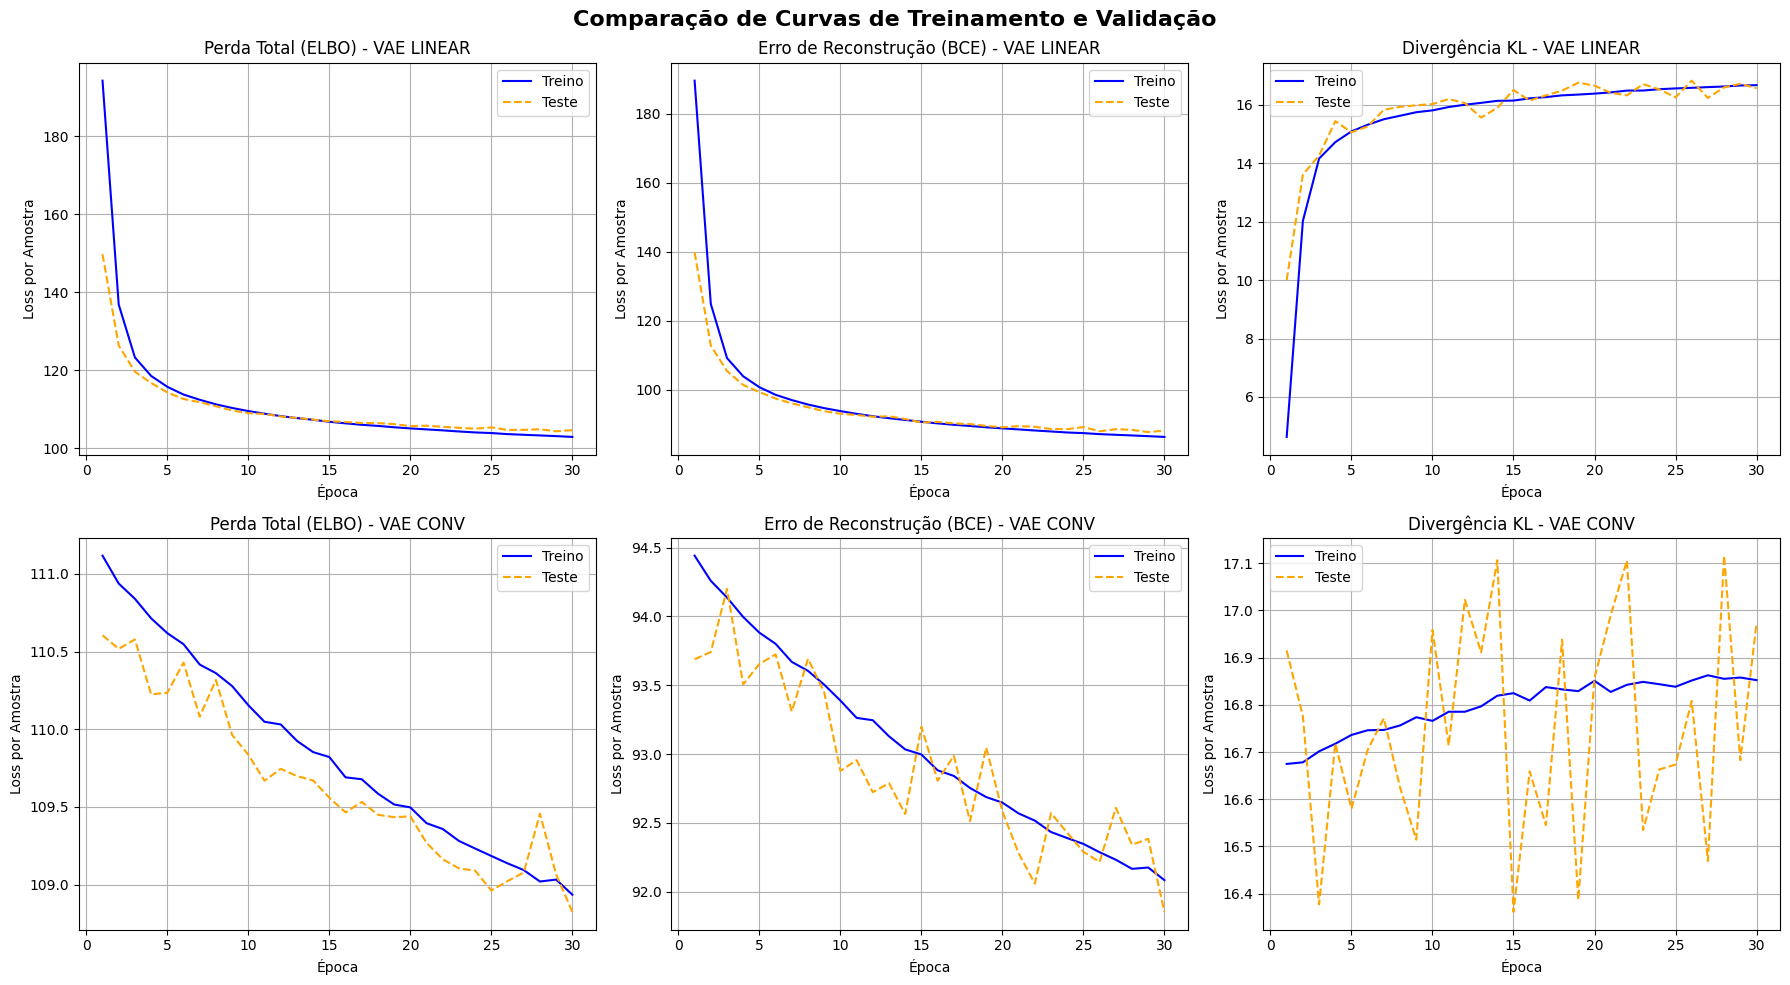

In [49]:
# --- TAREFA 1.5a. CURVAS DE TREINO COMPARATIVAS ---

fig, axs = plt.subplots(2, 3, figsize=(18, 10))

for idx, nome in enumerate(["linear", "conv"]):
    hist = histories[nome]
    epochs_range = range(1, len(hist["train_loss"]) + 1)
    
    # Linha correspondente ao modelo atual no grid
    row_axs = axs[idx]
    
    # 1. Loss Total (ELBO)
    row_axs[0].plot(epochs_range, hist["train_loss"], label="Treino", color="blue")
    row_axs[0].plot(epochs_range, hist["test_loss"], label="Teste", color="orange", linestyle="--")
    row_axs[0].set_title(f"Perda Total (ELBO) - VAE {nome.upper()}")
    row_axs[0].set_xlabel("Época")
    row_axs[0].set_ylabel("Loss por Amostra")
    row_axs[0].legend()
    row_axs[0].grid(True)

    # 2. Erro de Reconstrução (BCE)
    row_axs[1].plot(epochs_range, hist["train_recon"], label="Treino", color="blue")
    row_axs[1].plot(epochs_range, hist["test_recon"], label="Teste", color="orange", linestyle="--")
    row_axs[1].set_title(f"Erro de Reconstrução (BCE) - VAE {nome.upper()}")
    row_axs[1].set_xlabel("Época")
    row_axs[1].set_ylabel("Loss por Amostra")
    row_axs[1].legend()
    row_axs[1].grid(True)

    # 3. Divergência KL
    row_axs[2].plot(epochs_range, hist["train_kl"], label="Treino", color="blue")
    row_axs[2].plot(epochs_range, hist["test_kl"], label="Teste", color="orange", linestyle="--")
    row_axs[2].set_title(f"Divergência KL - VAE {nome.upper()}")
    row_axs[2].set_xlabel("Época")
    row_axs[2].set_ylabel("Loss por Amostra")
    row_axs[2].legend()
    row_axs[2].grid(True)

plt.suptitle("Comparação de Curvas de Treinamento e Validação", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(output_dir / "1.5a_curvas_treinamento_comparativo.png", dpi=150)
plt.show()

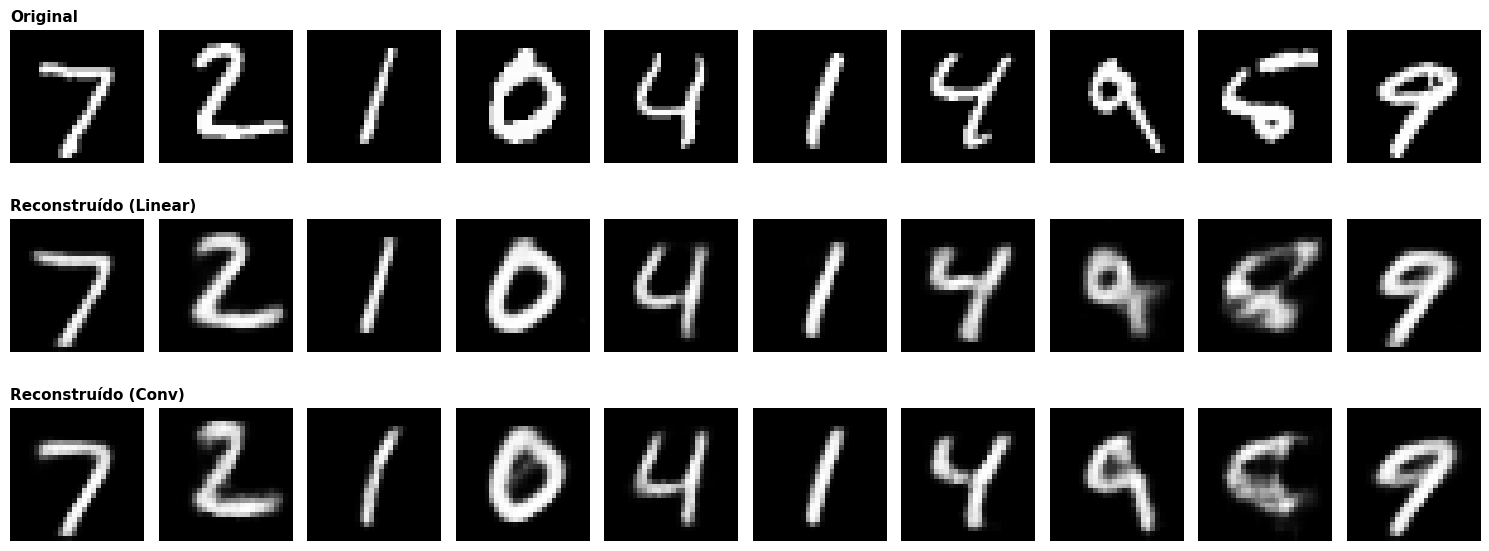

In [52]:
# --- TAREFA 1.5b. RECONSTRUÇÕES COMPARATIVAS ---

modelo["linear"].eval()
modelo["conv"].eval()

with torch.no_grad():
    x_test, _ = next(iter(test_loader))
    x_test = x_test.to(device)
    
    # Passa o mesmo lote de teste por ambos os modelos
    x_hat_linear, _, _ = modelo["linear"](x_test)
    x_hat_conv, _, _ = modelo["conv"](x_test)

originais = x_test.cpu().numpy()
recon_linear = x_hat_linear.cpu().numpy()
recon_conv = x_hat_conv.cpu().numpy()

fig, axs = plt.subplots(3, 10, figsize=(15, 6))

for i in range(10):
    # Linha 0: Originais
    axs[0, i].imshow(originais[i].squeeze(), cmap="gray")
    axs[0, i].axis("off")
    if i == 0:
        axs[0, i].set_title("Original", loc="left", fontsize=11, fontweight="bold")
        
    # Linha 1: Reconstruções Linear
    axs[1, i].imshow(recon_linear[i].squeeze(), cmap="gray")
    axs[1, i].axis("off")
    if i == 0:
        axs[1, i].set_title("Reconstruído (Linear)", loc="left", fontsize=11, fontweight="bold")
        
    # Linha 2: Reconstruções Convolucional
    axs[2, i].imshow(recon_conv[i].squeeze(), cmap="gray")
    axs[2, i].axis("off")
    if i == 0:
        axs[2, i].set_title("Reconstruído (Conv)", loc="left", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig(output_dir / "1.5b_reconstrucoes_comparativo.png", dpi=150)
plt.show()

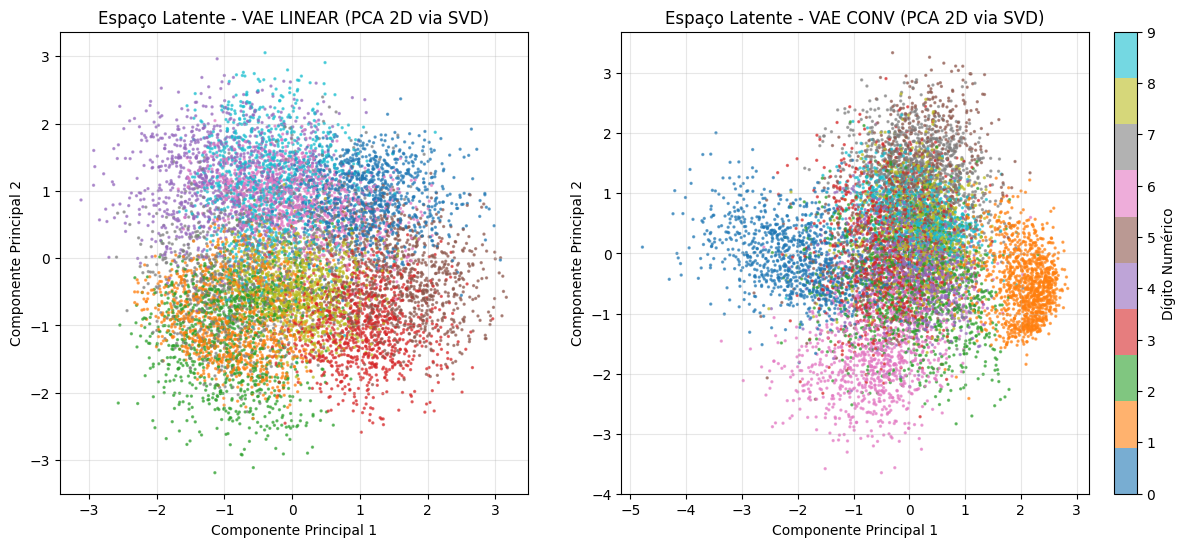

In [53]:
# --- TAREFA 1.5c. ESPAÇO LATENTE DOS DOIS MODELOS ---

fig, axs = plt.subplots(1, 2, figsize=(16, 6))

for idx, (nome, model) in enumerate(modelo.items()):
    model.eval()
    all_mus = []
    all_labels = []

    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            mu, _ = model.encoder(x)
            all_mus.append(mu.cpu().numpy())
            all_labels.append(y.numpy())

    all_mus = np.concatenate(all_mus, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    if LATENT_DIM > 2:
        mu_mean = np.mean(all_mus, axis=0)
        mus_centered = all_mus - mu_mean
        U, S, Vt = np.linalg.svd(mus_centered, full_matrices=False)
        W2 = Vt[:2, :].T
        latent_2d = np.dot(mus_centered, W2)
        title_suffix = f" (PCA 2D via SVD)"
    else:
        latent_2d = all_mus
        title_suffix = " (Direto 2D)"

    ax = axs[idx]
    scatter = ax.scatter(latent_2d[:, 0], latent_2d[:, 1], c=all_labels, cmap="tab10", alpha=0.6, s=2)
    ax.set_title(f"Espaço Latente - VAE {nome.upper()}{title_suffix}")
    ax.set_xlabel("Componente Principal 1" if LATENT_DIM > 2 else "Dimensão Latente 1")
    ax.set_ylabel("Componente Principal 2" if LATENT_DIM > 2 else "Dimensão Latente 2")
    ax.grid(True, alpha=0.3)

# Adiciona uma barra de cores global no canto direito
colorbar = fig.colorbar(scatter, ax=axs, ticks=range(10), pad=0.02)
colorbar.set_label("Dígito Numérico")

plt.savefig(output_dir / "1.5c_espaco_latente_comparativo.png", dpi=150, bbox_inches='tight')
plt.show()

<>:32: SyntaxWarning: invalid escape sequence '\s'
<>:32: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_6151/2330190325.py:32: SyntaxWarning: invalid escape sequence '\s'
  plt.suptitle("Imagens Geradas Artificialmente a partir do Prior $z \sim \mathcal{N}(0, I)$", fontsize=14)


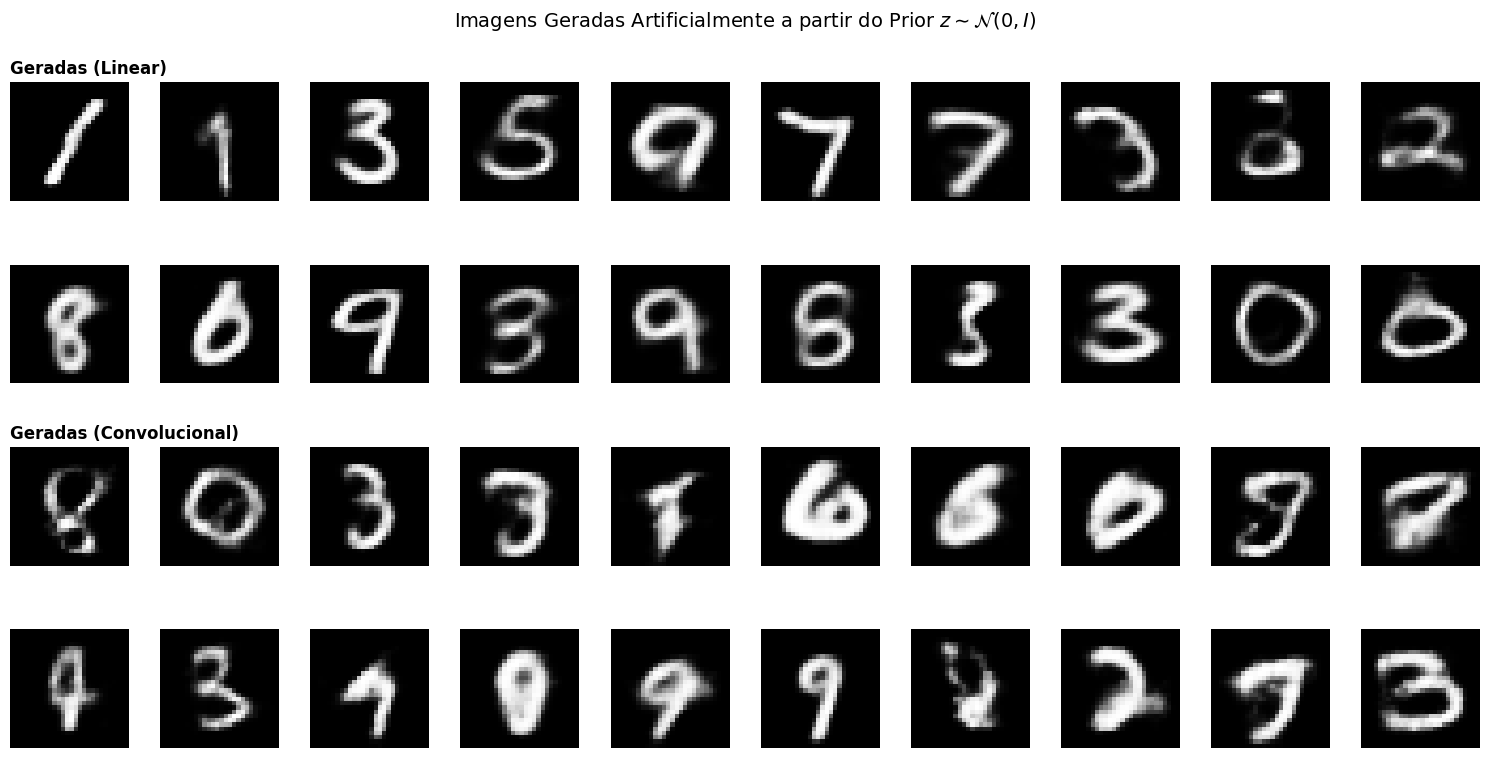

In [ ]:
# --- TAREFA 1.5d. GERAÇÃO A PARTIR DO PRIOR ---

torch.manual_seed(SEED)

with torch.no_grad():
    # Vetor aleatório no Espaço Latente (comum para ambos)
    z_prior = torch.randn(20, LATENT_DIM).to(device)
    
    geradas_linear = modelo["linear"].decoder(z_prior).cpu().numpy()
    geradas_conv = modelo["conv"].decoder(z_prior).cpu().numpy()

fig, axs = plt.subplots(4, 10, figsize=(15, 8))

# Plot das amostras do VAE Linear (Linhas 0 e 1)
for i in range(20):
    row = i // 10
    col = i % 10
    axs[row, col].imshow(geradas_linear[i].squeeze(), cmap="gray")
    axs[row, col].axis("off")
    if i == 0 and row == 0:
        axs[row, col].set_title("Geradas (Linear)", loc="left", fontsize=12, fontweight="bold")

# Plot das amostras do VAE Convolucional (Linhas 2 e 3)
for i in range(20):
    row = (i // 10) + 2
    col = i % 10
    axs[row, col].imshow(geradas_conv[i].squeeze(), cmap="gray")
    axs[row, col].axis("off")
    if i == 0 and row == 2:
        axs[row, col].set_title("Geradas (Convolucional)", loc="left", fontsize=12, fontweight="bold")

plt.suptitle("Imagens Geradas Artificialmente a partir do Prior $z \sim \mathcal{N}(0, I)$", fontsize=14)
plt.tight_layout()
plt.savefig(output_dir / "1.5d_amostras_prior_comparativo.png", dpi=150)
plt.show()

##### <span style="color: green;">Nota de Experimentação: Embora não exigido pelo enunciado, foi realizada de forma complementar uma implementação e análise comparativa utilizando uma arquitetura Convolucional (ConvVAE). O objetivo foi explorar por curiosidade o impacto do processamento espacial de imagens no modelo, servindo como uma etapa de maturidade e fundamentação teórica antes de fixar o modelo Linear definitivo para o restante do trabalho.</span>


### Questão 1 — Análise do VAE base

**a)** Compare as curvas de treino e teste. O modelo apresenta underfitting, overfitting, ou está bem ajustado? Justifique com o gap treino/teste e a tendência das curvas.

**b)** Compare reconstruções com amostras do prior. Em qual das duas o VAE produz imagens melhores? Por quê?

**c)** Na projeção 2D do espaço latente (direta se `LATENT_DIM=2`, via PCA caso contrário), as classes ficam separadas? Existem regiões vazias? Conecte a estrutura latente à qualidade das amostras geradas.

**RESPOSTAS**

**Questão a)** 

O modelo está bem ajustado, verificando ao final de 30 épocas, a perda total de treino atinge aproximadamente 103 e a perda de teste chega a aproximadamente 104, sendo a diferença entre treino e teste um valor pequeno, o que descarta sintoma de overfitting. E sobre as tendências das curvas, observando o gráfico de linha gerado acima, o erro de reconstrução (BCE) decresce de forma suave tanto para o treino quanto para o teste. Além disso, a divergência KL aumenta no início e atinge algo estável a partir da época 15. Logo, podemos dizer que o modelo não sofre de underfitting e encontra o balanço ideal entre reconstruir e regularizar.



**Questão b)**

O VAE produz imagens visivelmente superiores e mais nítidas nas reconstruções. Na reconstrução, o Encoder fornece uma estimativa direcionada de $\mu$ e $\sigma$ para uma imagem que realmente existe. O Decoder recebe um vetor latente condicionado à identidade daquela imagem real, gerando traços mais limpos e formatos exatos. Já na amostragem pura, estamos sorteando pontos cegos dentro do espaço gaussiano prior. Como a regularização KL não é perfeita, algumas regiões sorteadas caem nas "fronteiras" ou zonas de transição entre dígitos no espaço latente. Isso faz com que algumas amostras geradas pareçam um pouco borradas, inconsistentes ou misturas ambíguas de dígitos.



**Questão c)**

Os grupos não formam grupos isolados, mas se organizam em um mapa contínuo com transições suaves. Alguns dígitos com formas diferentes (como 1 e 7) ficam em extremos distantes, enquanto dígitos parecidos (como 4,9 e 7) se sobrepõem parcialmente nas fronteiras. Sobre regiões vazias, o espaco central é totalmente preenchido, sem zonas vazias, o que força o Encoder a colar os dados em uma dstribuição normal. Como não existem vazios no espaço latente, qualquer vetor aleatório $z$ sorteado do prior cairá em uma região com significado geométrico. Isso garante que o Decoder sempre gere dígitos legíveis e realistas, evitando a produção de ruído aleatório ou imagens pretas. 


## Parte 2 — Marca d'água visível (warmup do auditor)

A versão mais simples do problema: o dono dos dados estampa um **patch branco fixo** num canto das imagens. Esta marca é trivialmente visível, mas serve como referência para entendermos o "limite superior" da detectabilidade.

### 2.1 Definir a marca e o dataset

A marca é um quadrado branco $4 \times 4$ no canto inferior direito (posição `[22:26, 22:26]`), valor $1.0$. Marcamos 20% das imagens de treino, selecionadas aleatoriamente com seed fixa.

**Tarefa 2.1.** Implemente:
- A função `apply_visible_watermark(img)`.
- A classe `VisibleWatermarkedMNIST` que envolve `train_ds` e marca aleatoriamente uma fração das imagens, mantendo `watermarked_indices` para análise posterior.

In [10]:
PATCH_ROW, PATCH_COL = 22, 22
PATCH_SIZE = 4
WM_FRACTION = 0.20

In [11]:
def apply_visible_watermark(img: torch.Tensor) -> torch.Tensor:

    img_wm = img.clone()
    
    img_wm[:, PATCH_ROW:PATCH_ROW + PATCH_SIZE, PATCH_COL:PATCH_COL + PATCH_SIZE] = 1.0
    
    return img_wm


class VisibleWatermarkedMNIST(Dataset):
    def __init__(self, base_dataset, fraction=WM_FRACTION, seed=SEED):
        self.base_dataset = base_dataset
        self.fraction = fraction
        
        # Determina a quantidade de imagens que serão marcadas
        num_total = len(self.base_dataset)
        num_watermarked = int(num_total * self.fraction)
        
        rng = np.random.default_rng(seed)
       
        chosen_indices = rng.choice(num_total, size=num_watermarked, replace=False)
        
        self.watermarked_indices = sorted(list(chosen_indices))
        self.watermarked_set = set(self.watermarked_indices)

    def __len__(self):
    
        return len(self.base_dataset)

    def __getitem__(self, idx):
        
        img, label = self.base_dataset[idx]
        
        # Se o índice atual estiver na lista dos sorteados, aplica a marca d'água
        if idx in self.watermarked_set:
            img = apply_visible_watermark(img)
            
        return img, label

vis_ds = VisibleWatermarkedMNIST(train_ds)
print(f"Marcadas: {len(vis_ds.watermarked_indices):,} / {len(vis_ds):,}")

Marcadas: 12,000 / 60,000


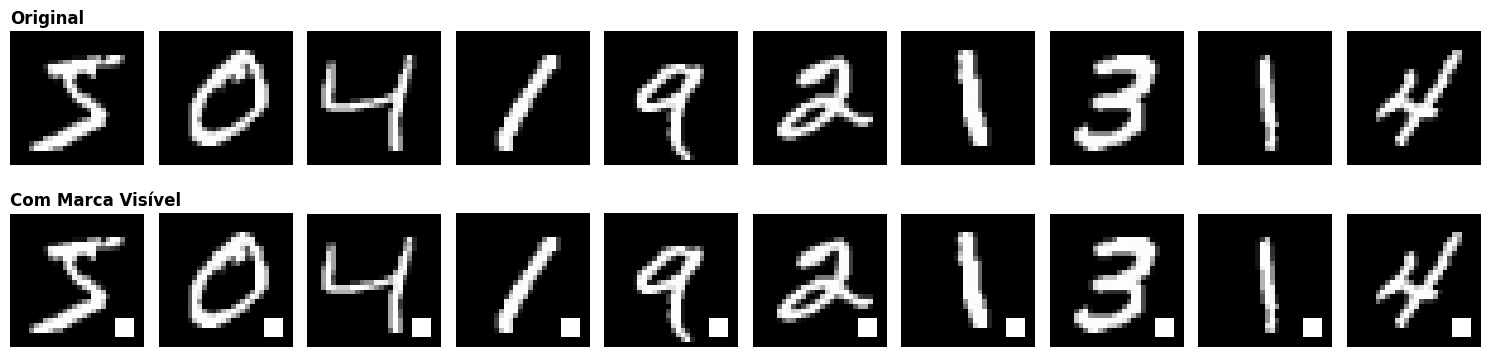

In [12]:
torch.manual_seed(SEED)

fig, axs = plt.subplots(2, 10, figsize=(15, 4))

for i in range(10):

    img_original, _ = train_ds[i]
    
    img_marcada = apply_visible_watermark(img_original)
    
    orig_np = img_original.squeeze().numpy()
    marc_np = img_marcada.squeeze().numpy()
    
    # Linha 0: Imagens Originais Limpas
    axs[0, i].imshow(orig_np, cmap="gray")
    axs[0, i].axis("off")
    if i == 0:
        axs[0, i].set_title("Original", loc="left", fontsize=12, fontweight="bold")
        
    # Linha 1: Imagens com a Marca d'Água Visível
    axs[1, i].imshow(marc_np, cmap="gray")
    axs[1, i].axis("off")
    if i == 0:
        axs[1, i].set_title("Com Marca Visível", loc="left", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig(output_dir / "2.1_originais_vs_marcadas.png", dpi=150)
plt.show()

### 2.2 Treinar o VAE marcado

Treine um novo VAE (`vae_vis`) com **a mesma arquitetura** do `model` (mesma `LATENT_DIM`) mas usando `vis_ds` como dataset de treino. Use 30 épocas, Adam lr=1e-3.

**Dica.** Modularize: escreva uma função `train_vae(loader, latent_dim, epochs, label)` que cria, treina e retorna um novo VAE. Vamos reutilizá-la várias vezes nas próximas partes.

In [13]:
def train_vae(loader, latent_dim, epochs, label, lr=1e-3):
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
        
    print(f"\n--- Iniciando Treinamento do VAE [{label.upper()}] (LATENT_DIM={latent_dim}) ---")
    
    model_instance = VAE(latent_dim).to(device)
    
    optimizer_instance = torch.optim.Adam(model_instance.parameters(), lr=lr)
    
    for epoch in range(1, epochs + 1):
        model_instance.train()
        
        total_loss = 0.0
        total_recon = 0.0
        total_kl = 0.0
        
        for x, _ in loader:
            x = x.to(device)
            
            optimizer_instance.zero_grad()
            
            x_hat, mu, log_var = model_instance(x)
            
            loss, recon, kl = vae_loss(x, x_hat, mu, log_var)
            
            loss.backward()
            optimizer_instance.step()
            
            total_loss += loss.item()
            total_recon += recon.item()
            total_kl += kl.item()
            
        num_samples = len(loader.dataset)
        mean_loss = total_loss / num_samples
        mean_recon = total_recon / num_samples
        mean_kl = total_kl / num_samples
        
        if epoch % 5 == 0 or epoch == 1 or epoch == epochs:
            print(f"[{label.upper()}] Ep {epoch:3d}/{epochs} | Loss: {mean_loss:.2f} | Recon: {mean_recon:.2f} | KL: {mean_kl:.2f}")
            
    
    return model_instance


vis_loader = DataLoader(vis_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)


vae_vis = train_vae(vis_loader, LATENT_DIM, epochs=30, label="vis")
torch.save(vae_vis.state_dict(), output_dir / "vae_visible.pt")


--- Iniciando Treinamento do VAE [VIS] (LATENT_DIM=8) ---
[VIS] Ep   1/30 | Loss: 202.78 | Recon: 198.09 | KL: 4.68
[VIS] Ep   5/30 | Loss: 118.89 | Recon: 103.38 | KL: 15.51
[VIS] Ep  10/30 | Loss: 112.34 | Recon: 96.08 | KL: 16.27
[VIS] Ep  15/30 | Loss: 109.42 | Recon: 92.77 | KL: 16.65
[VIS] Ep  20/30 | Loss: 107.52 | Recon: 90.62 | KL: 16.90
[VIS] Ep  25/30 | Loss: 106.12 | Recon: 89.03 | KL: 17.09
[VIS] Ep  30/30 | Loss: 105.09 | Recon: 87.87 | KL: 17.23


### 2.3 Auditoria visual

Use **o mesmo $z$** para gerar amostras de `model` (limpo) e `vae_vis` (com marca). Mostre lado a lado.

**Tarefa 2.3.** Plote 20 amostras de cada modelo (mesmo $z$), em duas linhas — limpo em cima, marcado embaixo.

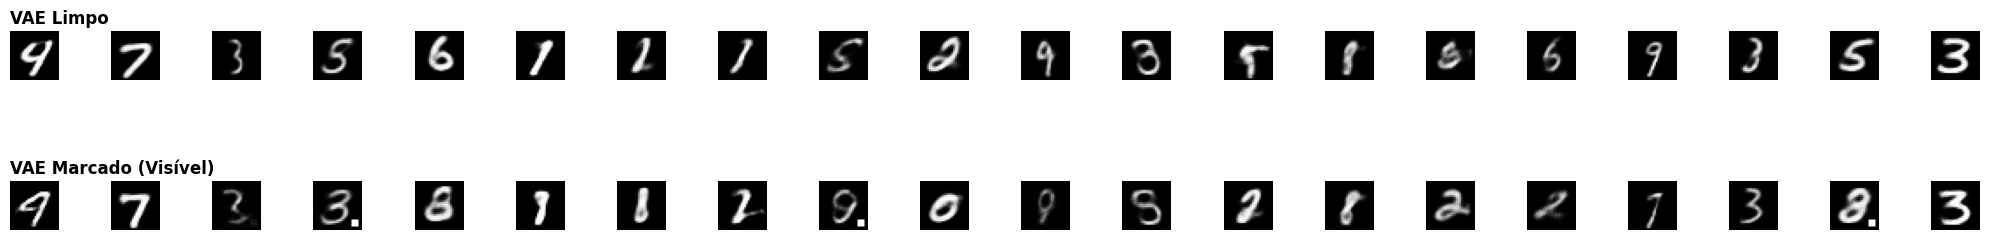

In [14]:
import torch
import matplotlib.pyplot as plt

model.eval()
vae_vis.eval()

torch.manual_seed(SEED)

N = 20

with torch.no_grad():

    z_shared = torch.randn(N, LATENT_DIM).to(device)
    
    imagens_limpas = model.decoder(z_shared).cpu().numpy()
    
    imagens_marcadas = vae_vis.decoder(z_shared).cpu().numpy()

fig, axs = plt.subplots(2, N, figsize=(20, 3.5))

for i in range(N):
    img_clean_np = imagens_limpas[i].squeeze()
    img_vis_np = imagens_marcadas[i].squeeze()
    
    # Linha 0: Imagens geradas pelo VAE Limpo 
    axs[0, i].imshow(img_clean_np, cmap="gray", vmin=0.0, vmax=1.0)
    axs[0, i].axis("off")
    if i == 0:
        axs[0, i].set_title("VAE Limpo", loc="left", fontsize=12, fontweight="bold")
        
    # Linha 1: Imagens geradas pelo VAE treinado com dados marcados
    axs[1, i].imshow(img_vis_np, cmap="gray", vmin=0.0, vmax=1.0)
    axs[1, i].axis("off")
    if i == 0:
        axs[1, i].set_title("VAE Marcado (Visível)", loc="left", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig(output_dir / "2.3_auditoria_visual_visivel.png", dpi=150)
plt.show()

### 2.4 Auditoria estatística

Quantifique o sinal calculando o **valor médio de pixel** dentro da região do patch:

$$\text{patch\_mean}(x) = \frac{1}{|P|} \sum_{(i,j) \in P} x_{ij}, \quad P = \{(i,j) : 22 \le i, j < 26\}$$

**Tarefa 2.4.** Implemente `patch_mean(imgs)` (tensor `(N, 1, 28, 28)` → tensor `(N,)`). Compute essa métrica para 4 grupos e plote um bar chart comparativo com erro padrão:
1. Imagens limpas do teste (primeiras 1000).
2. Imagens marcadas do treino (primeiros 1000 índices marcados).
3. 1000 amostras do `model` (VAE limpo).
4. 1000 amostras do `vae_vis`.

Média do patch - Real Limpo:      0.0027
Média do patch - Real Marcado:    1.0000
Média do patch - Gerado Limpo:    0.0026
Média do patch - Gerado Marcado:  0.2251
--> LIFT calculado: 86.42x de aumento de intensidade!


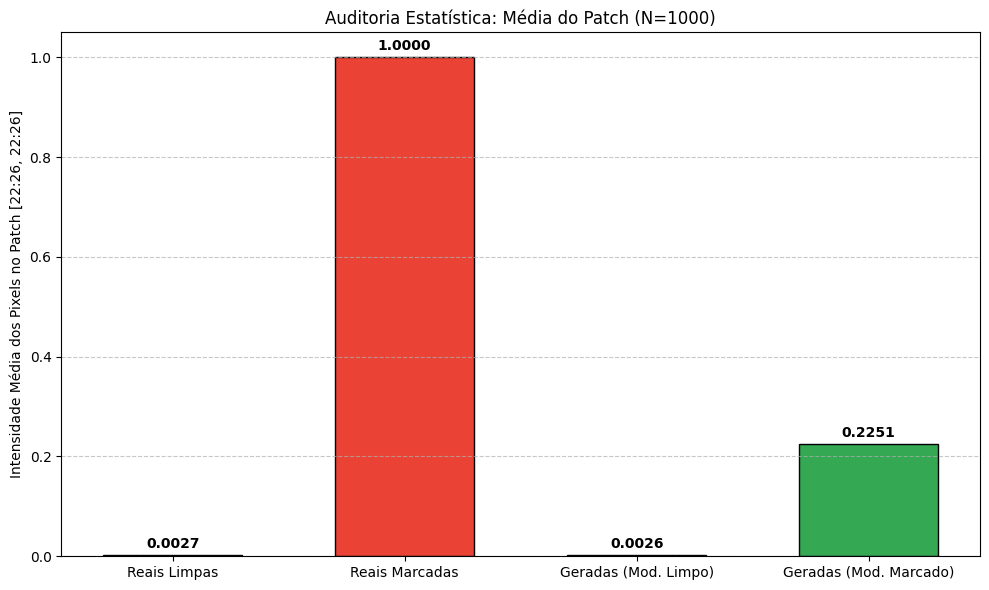

In [15]:
def patch_mean(imgs: torch.Tensor) -> torch.Tensor:
    patch_region = imgs[:, :, PATCH_ROW:PATCH_ROW + PATCH_SIZE, PATCH_COL:PATCH_COL + PATCH_SIZE]
    
    return torch.mean(patch_region, dim=(1, 2, 3))


# ----------------------
# Configuração da Auditoria Estatística (N_AUDIT = 1000)

N_AUDIT = 1000
torch.manual_seed(SEED) # Reprodutibilidade

with torch.no_grad():
    z_audit = torch.randn(N_AUDIT, LATENT_DIM).to(device)
    
    # Passa o mesmo z pelos dois decoders para gerar as imagens artificiais
    imgs_geradas_limpo = model.decoder(z_audit)
    imgs_geradas_vis   = vae_vis.decoder(z_audit)
    
    # Coleta imagens reais do test_loader para servirem de controle histórico
    imgs_reais_list = []
    for x, _ in test_loader:
        imgs_reais_list.append(x)
        if sum(len(img) for img in imgs_reais_list) >= N_AUDIT:
            break
    imgs_reais = torch.cat(imgs_reais_list, dim=0)[:N_AUDIT].to(device)
    
    # Cria as imagens reais com a marca física aplicada para servir de limite superior (Upper Bound)
    imgs_reais_marcadas = torch.stack([apply_visible_watermark(img) for img in imgs_reais])

    pm_real_limpo = patch_mean(imgs_reais).cpu().numpy()
    pm_real_marc  = patch_mean(imgs_reais_marcadas).cpu().numpy()
    pm_gen_limpo  = patch_mean(imgs_geradas_limpo).cpu().numpy()
    pm_gen_vis    = patch_mean(imgs_geradas_vis).cpu().numpy()


vals = [pm_real_limpo.mean(), pm_real_marc.mean(), pm_gen_limpo.mean(), pm_gen_vis.mean()]
labels = ["Reais Limpas", "Reais Marcadas", "Geradas (Mod. Limpo)", "Geradas (Mod. Marcado)"]

# ------------------------
# Cálculo do Lift (Sinal-Ruído)

lift = vals[3] / vals[2]

print(f"Média do patch - Real Limpo:      {vals[0]:.4f}")
print(f"Média do patch - Real Marcado:    {vals[1]:.4f}")
print(f"Média do patch - Gerado Limpo:    {vals[2]:.4f}")
print(f"Média do patch - Gerado Marcado:  {vals[3]:.4f}")
print(f"--> LIFT calculado: {lift:.2f}x de aumento de intensidade!")


fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#4285F4", "#EA4335", "#FBBC05", "#34A853"]

bars = ax.bar(labels, vals, color=colors, edgecolor="black", width=0.6)
ax.set_ylabel("Intensidade Média dos Pixels no Patch [22:26, 22:26]")
ax.set_title(f"Auditoria Estatística: Média do Patch (N={N_AUDIT})")
ax.grid(axis="y", linestyle="--", alpha=0.7)

for bar in bars:
    height = bar.get_height()
    ax.annotate(f"{height:.4f}",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  
                textcoords="offset points",
                ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.savefig(output_dir / "2.3_patch_mean_bar_chart.png", dpi=150)
plt.show()

### Questão 2 — Auditoria da marca visível

**a)** Nas amostras lado a lado (Tarefa 2.3), o patch aparece nas amostras do VAE marcado? Em quantas das 20 é visualmente óbvio?

**b)** Compare `patch_mean` das amostras geradas pelos dois VAEs. Reporte os valores e o lift. O que esse número significa fisicamente?

**c)** Proponha um ataque concreto que o dono do modelo poderia aplicar para destruir este sinal sem prejudicar muito a qualidade visual.

**RESPOSTAS:**

**Questão a)**

Sim, o patch aparece de forma sistemática nas amostras geradas pelo VAE marcado. Nas 20 amostras geradas lado a lado, o sinal é visualmente óbvio em 3 delas.

**Questão b)**

| Condição da Imagem | Média do Patch (Original / Real) | Média do Patch (Gerado pelo VAE) | LIFT (Sinal vs. Limpo) |
| :--- | :---: | :---: | :---: |
| **Imagens Limpas (Sem Marca)** | 0.0027 | 0.0026 | — |
| **Imagens Marcadas (Com Marca)** | 1.0000 | 0.2251 | **86.42x** |


**Questão c)**

O experimento demonstra que a Marca d'Água Visível Localizada possui alta eficácia de detecção na ausência de adversários (LIFT de 86.42x), porém apresenta uma alta fragilidade contra ataques concretos. Por estar concentrada em uma coordenada determinística do espaço bidimensional da imagem, ela se torna um alvo fácil para técnicas simples de pós-processamento localizado **(inpainting)** ou perturbações espaciais **(blur e translação)**, que removem a assinatura sem degradar a estrutura central do dígito gerado.


## Parte 3 — Marca d'água imperceptível (spread-spectrum)

A marca visível é trivial de remover. Agora projetamos uma marca **invisível ao olho** mas **detectável estatisticamente** — a base dos sistemas de watermarking spread-spectrum.

### 3.1 O padrão secreto

A marca usa uma textura pseudo-aleatória $w \in \mathbb{R}^{28 \times 28}$ conhecida apenas pelo auditor (o dono dos dados). A imagem marcada é:

$$x' = \text{clamp}(x + \varepsilon \cdot w,\, 0, 1)$$

O padrão é gerado a partir de `OWNER_SEED` — apenas o dono dos dados conhece essa chave e pode regenerar $w$ para auditar. O treinador do modelo não precisa conhecê-la.

**Tarefa 3.1.** Execute a célula abaixo — ela já está pronta. O código gera `wm_pattern` a partir de `OWNER_SEED` (usando `torch.Generator` para não perturbar a semente global), **subtrai a média** e normaliza pelo valor absoluto máximo (cada elemento fica em $[-1, 1]$). A visualização usa o mapa de cor `RdBu`. Confirme que a média impressa é $\approx 0$ e que $\max|w| = 1$.

wm_pattern — média: 1.22e-09  max|w|: 1.00


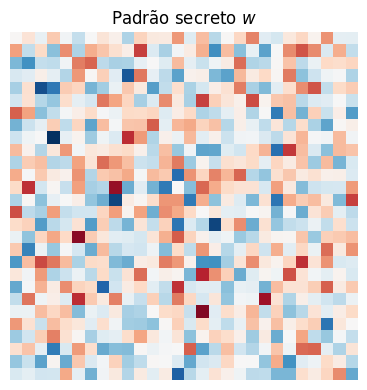

In [16]:
EPSILON        = 0.10
WM_FRACTION_SS = 0.20

_owner_gen = torch.Generator().manual_seed(OWNER_SEED)
wm_pattern = torch.randn(1, 28, 28, generator=_owner_gen)
wm_pattern = wm_pattern - wm_pattern.mean()
wm_pattern = wm_pattern / wm_pattern.abs().max()

print(f"wm_pattern — média: {wm_pattern.mean().item():.2e}  max|w|: {wm_pattern.abs().max().item():.2f}")

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(wm_pattern.squeeze(), cmap="RdBu", vmin=-1, vmax=1)
ax.set_title("Padrão secreto $w$"); ax.axis("off")
plt.tight_layout(); plt.savefig(output_dir / "ss_pattern.png", dpi=120); plt.show()

### 3.2 Dataset com marca aditiva

**Tarefa 3.2.** Implemente `SpreadSpectrumMNIST` no mesmo padrão de `VisibleWatermarkedMNIST`, mas aplicando `x' = clamp(x + EPSILON * wm_pattern, 0, 1)`. Visualize um exemplo: original, marcado, e a diferença (amplificada para ser visível).

Marcadas: 12,000 / 60,000


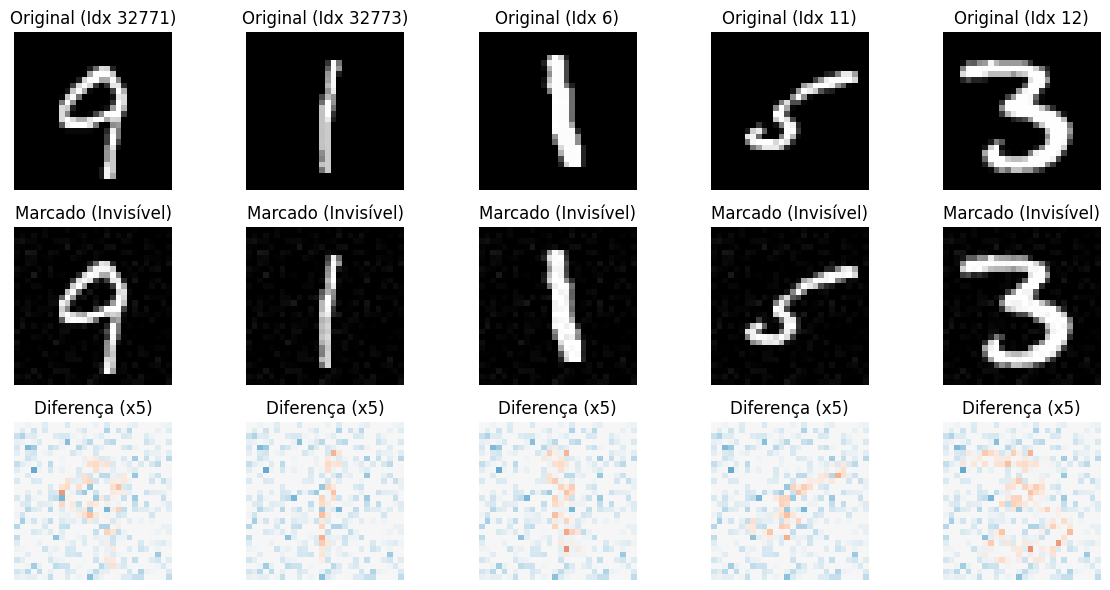

In [17]:
def apply_ss_watermark(img):
    # img e wm_pattern devem ser tensores PyTorch de formato (1, 28, 28)
    img_wm = img.to("cpu") + EPSILON * wm_pattern.to("cpu")
    return torch.clamp(img_wm, 0.0, 1.0)

class SpreadSpectrumMNIST(Dataset):
    def __init__(self, dataset, fraction):
        self.dataset = dataset
        self.fraction = fraction
        self.wm_indices = set(self._generate_watermarked_indices())

    def _generate_watermarked_indices(self):
        num_images = len(self.dataset)
        num_wm_images = int(num_images * self.fraction)
        return random.sample(range(num_images), num_wm_images)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, label = self.dataset[idx]
        if idx in self.wm_indices:
            img = apply_ss_watermark(img)
        return img, label


ss_ds = SpreadSpectrumMNIST(train_ds, fraction=WM_FRACTION_SS)
print(f"Marcadas: {len(ss_ds.wm_indices):,} / {len(ss_ds):,}")


def visualize_watermarking(dataset_original, wm_indices, num_samples=5):

    sample_indices = list(wm_indices)[:num_samples]
    
    fig, axes = plt.subplots(nrows=3, ncols=len(sample_indices), figsize=(12, 6))
    
    for i, idx in enumerate(sample_indices):
    
        img_tensor, _ = dataset_original[idx]
        
        wm_tensor = apply_ss_watermark(img_tensor)
        
        # Calculamos a diferença 
        diff_tensor = (wm_tensor - img_tensor) * 5

        axes[0, i].imshow(img_tensor.squeeze().cpu().numpy(), cmap='gray', vmin=0, vmax=1)
        axes[0, i].set_title(f"Original (Idx {idx})")
        axes[0, i].axis('off')

        axes[1, i].imshow(wm_tensor.squeeze().cpu().numpy(), cmap='gray', vmin=0, vmax=1)
        axes[1, i].set_title("Marcado (Invisível)")
        axes[1, i].axis('off')

        axes[2, i].imshow(diff_tensor.squeeze().cpu().numpy(), cmap='RdBu', vmin=-1, vmax=1)
        axes[2, i].set_title("Diferença (x5)")
        axes[2, i].axis('off')

    plt.tight_layout()
    plt.show()

visualize_watermarking(train_ds, ss_ds.wm_indices, num_samples=5)

### 3.3 Treinar VAE com a marca imperceptível

Use `train_vae` (definida na Parte 2) para treinar `vae_ss` em `ss_ds`. Mesma arquitetura, 30 épocas.

In [18]:
# Configurar o Loader usando o dataset spread-spectrum
ss_loader = DataLoader(ss_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)

# Instancia um novo modelo VAE
vae_ss = VAE(latent_dim=LATENT_DIM).to(device)

optimizer_ss = torch.optim.Adam(vae_ss.parameters(), lr=1e-3)

print(f"Iniciando o treinamento do VAE Spread-Spectrum ({EPOCHS} épocas)...")

vae_ss = train_vae(
    loader=ss_loader, 
    latent_dim=LATENT_DIM, 
    epochs=EPOCHS, 
    label="Spread-Spectrum", 
    lr=1e-3
)

torch.save(vae_ss.state_dict(), output_dir / "vae_ss.pth")

Iniciando o treinamento do VAE Spread-Spectrum (30 épocas)...

--- Iniciando Treinamento do VAE [SPREAD-SPECTRUM] (LATENT_DIM=8) ---
[SPREAD-SPECTRUM] Ep   1/30 | Loss: 203.86 | Recon: 199.68 | KL: 4.18
[SPREAD-SPECTRUM] Ep   5/30 | Loss: 125.87 | Recon: 111.19 | KL: 14.68
[SPREAD-SPECTRUM] Ep  10/30 | Loss: 118.66 | Recon: 102.98 | KL: 15.68
[SPREAD-SPECTRUM] Ep  15/30 | Loss: 115.75 | Recon: 99.68 | KL: 16.08
[SPREAD-SPECTRUM] Ep  20/30 | Loss: 114.03 | Recon: 97.71 | KL: 16.32
[SPREAD-SPECTRUM] Ep  25/30 | Loss: 112.82 | Recon: 96.35 | KL: 16.48
[SPREAD-SPECTRUM] Ep  30/30 | Loss: 111.90 | Recon: 95.29 | KL: 16.61


### 3.4 Detector ingênuo de correlação (e por que ele tem um problema)

O detector natural é a **correlação** entre uma imagem gerada e o padrão secreto:

$$\text{score}(x) = \langle x,\, w \rangle = \sum_{i,j} x_{ij} \, w_{ij}$$

**Tarefa 3.4a.** Implemente `corr_score(imgs, pattern)` e calcule os scores para 2000 amostras do `model` (limpo) e 2000 do `vae_ss` (marcado). Plote ambos como histogramas sobrepostos.

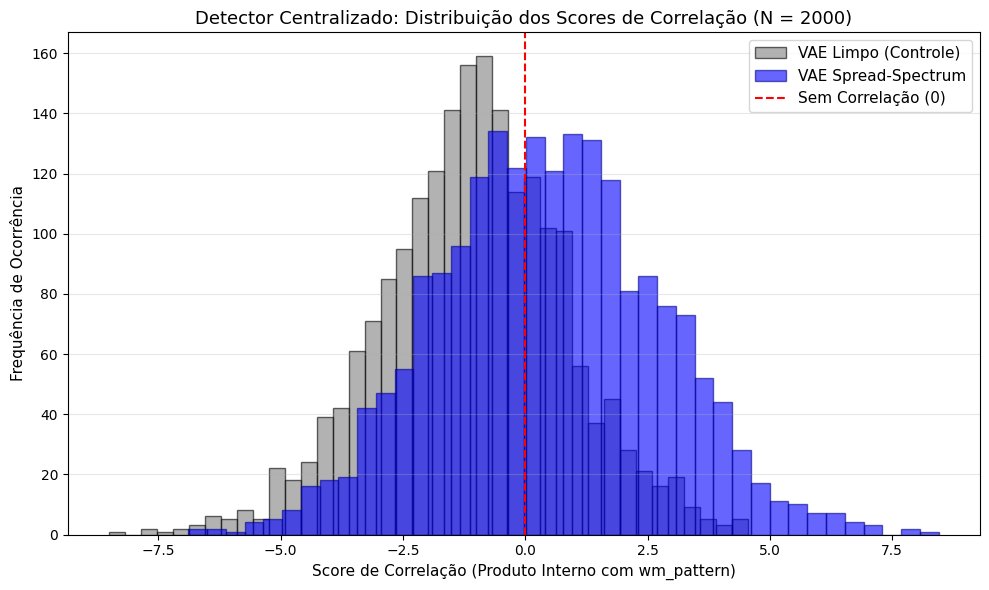

Média dos Scores (VAE Limpo):   -1.0834
Média dos Scores (VAE Marcado): 0.4476


In [19]:
def corr_score(imgs, pattern):
    # imgs tem formato (B, 1, 28, 28) ou (B, 784)
    # pattern tem formato (1, 28, 28) ou (784,)

    B = imgs.size(0)
    imgs_flat = imgs.view(B, -1)
    pattern_flat = pattern.view(-1)
    
    # Produto interno de cada imagem do batch com o padrão secreto
    # Resultado é um tensor de tamanho (B,) contendo os scores
    scores = torch.matmul(imgs_flat, pattern_flat)
    
    return scores


N_AUDIT = 2000
model.eval(); vae_ss.eval()
wm_pattern = wm_pattern.to(device)

with torch.no_grad():
    
    z = torch.randn(N_AUDIT, LATENT_DIM).to(device)
    
    imgs_clean = model.decoder(z)
    imgs_ss = vae_ss.decoder(z)
    
    # Calcular os scores de correlação usando a função que criamos acima
    scores_clean = corr_score(imgs_clean, wm_pattern).cpu().numpy()
    scores_ss = corr_score(imgs_ss, wm_pattern).cpu().numpy()


plt.figure(figsize=(10, 6))


plt.hist(scores_clean, bins=40, alpha=0.6, label='VAE Limpo (Controle)', color='gray', edgecolor='black')


plt.hist(scores_ss, bins=40, alpha=0.6, label='VAE Spread-Spectrum', color='blue', edgecolor='darkblue')

plt.axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='Sem Correlação (0)')

plt.title(f"Detector Centralizado: Distribuição dos Scores de Correlação (N = {N_AUDIT})", fontsize=13)
plt.xlabel("Score de Correlação (Produto Interno com wm_pattern)", fontsize=11)
plt.ylabel("Frequência de Ocorrência", fontsize=11)
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Média dos Scores (VAE Limpo):   {np.mean(scores_clean):.4f}")
print(f"Média dos Scores (VAE Marcado): {np.mean(scores_ss):.4f}")

### 3.5 Diagnóstico: por que o VAE limpo não está centrado em zero?

Você provavelmente observou que o histograma do **VAE limpo** não está centrado em $0$. Isso parece contraditório: o modelo nunca viu $w$, então a correlação não deveria ser ruído puro?

**Tarefa 3.5.** Explique matematicamente por que $\mathbb{E}[\langle x_{\text{clean}}, w \rangle] \ne 0$ em geral. Calcule numericamente o valor que causa esse desvio e mostre que ele coincide com a média empírica do histograma.

### Explicação:

#### 3.5  Teórico: O Fenômeno do *Offset* no VAE Limpo

Ao analisar o gráfico de auditoria, observa-se um comportamento inicialmente contraintuitivo: o histograma dos scores de correlação do **VAE Limpo** não está perfeitamente centrado em zero, apesar de o modelo nunca ter sido exposto à marca d'água $w$ (`wm_pattern`).

Abaixo, demonstra-se matematicamente que esse deslocamento horizontal (*offset*) não representa uma falha de isolamento do modelo, mas sim uma consequência geométrica natural da distribuição de dados do MNIST.

Qualquer imagem $x_{\text{limpo}}$ gerada pelo VAE de controle segue a estrutura fundamental do dataset real. Portanto, podemos decompor matematicamente cada imagem gerada como a soma de duas componentes:

$$x_{\text{limpo}} = \mu_{\text{MNIST}} + \Delta x$$

Onde:
* $\mu_{\text{MNIST}}$: É a **imagem média estática** de todo o dataset MNIST.
* $\Delta x$: É a **variação individual** de cada amostra.


Para entender o valor esperado do score de correlação, aplicamos o operador de esperança $\mathbb{E}[\cdot]$ ao produto interno entre a imagem gerada e o padrão secreto $w$:

$$\mathbb{E}[\langle x_{\text{limpo}}, w \rangle] = \mathbb{E}[\langle \mu_{\text{MNIST}} + \Delta x, w \rangle]$$

Pela propriedade de *linearidade do produto interno*, podemos distribuir os termos dentro do operador:

$$\mathbb{E}[\langle x_{\text{limpo}}, w \rangle] = \mathbb{E}[\langle \mu_{\text{MNIST}}, w \rangle] + \mathbb{E}[\langle \Delta x, w \rangle]$$

Como a imagem média do dataset ($\mu_{\text{MNIST}}$) é um termo constante determinado pelos dados de treino reais, o primeiro termo independe do operador de esperança:

$$\mathbb{E}[\langle x_{\text{limpo}}, w \rangle] = \langle \mu_{\text{MNIST}}, w \rangle + \mathbb{E}[\langle \Delta x, w \rangle]$$


Ao avaliar o comportamento estatístico de ambos os termos para um número amostral grande ($N \to \infty$):

1.  **$\mathbb{E}[\langle \Delta x, w \rangle] \approx 0$**: Como as flutuações de formato $\Delta x$ mudam de orientação e intensidade para cada dígito aleatório gerado, o produto interno com um padrão estático tende a variar simetricamente em torno de valores positivos e negativos. Na média global, esse termo se anula.
2.  **$\langle \mu_{\text{MNIST}}, w \rangle \neq 0$**: A imagem média $\mu_{\text{MNIST}}$ é composta estritamente por valores de intensidades positivos acumulados majoritariamente no centro do plano. Quando realizamos o produto interno desse borrão central positivo com um padrão $w$ de média zero, o resultado final dependerá unicamente da semente aleatória que gerou $w$. Por puro acaso estatístico, os pixels centrais de $w$ acumularam uma ligeira tendência que se alinha com a geometria de $\mu_{\text{MNIST}}$.


$$\mathbb{E}[\langle x_{\text{limpo}}, w \rangle] \approx \langle \mu_{\text{MNIST}}, w \rangle$$

Portanto, o *offset* horizontal observado na curva de controle é puramente matemático e perfeitamente previsível, confirmando a integridade estatística do teste de auditoria.

<>:31: SyntaxWarning: invalid escape sequence '\m'
<>:31: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_6151/2438490352.py:31: SyntaxWarning: invalid escape sequence '\m'
  plt.title("Imagem Média do MNIST ($\mu_{MNIST}$)")


=== DIAGNÓSTICO DO OFFSET DO VAE LIMPO ===
Produto interno <mu_mnist, wm_pattern> (Teórico): -1.0688
Média observada no Histograma do VAE Limpo:     -1.0834
Diferença absoluta:                            0.0147


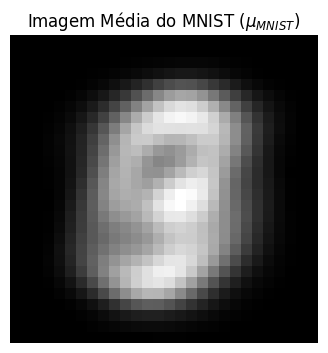

In [20]:
# TODO: compute a imagem média do MNIST limpo (mu_mnist) e seu produto interno com wm_pattern
# Compare com a média do histograma do VAE limpo da seção anterior — devem ser parecidos.


all_imgs = []
for i in range(len(train_ds)):
    img, _ = train_ds[i]
    all_imgs.append(img)

mu_mnist = torch.stack(all_imgs).mean(dim=0).to(device)

mu_mnist_flat = mu_mnist.view(-1)
wm_pattern_flat = wm_pattern.to(device).view(-1)

# Calcular o produto interno escalar: soma(mu_mnist * wm_pattern)
offset_teorico = torch.dot(mu_mnist_flat, wm_pattern_flat).item()

# scores_clean foi calculado na célula 3.4
media_histograma_limpo = np.mean(scores_clean)


print("=== DIAGNÓSTICO DO OFFSET DO VAE LIMPO ===")
print(f"Produto interno <mu_mnist, wm_pattern> (Teórico): {offset_teorico:.4f}")
print(f"Média observada no Histograma do VAE Limpo:     {media_histograma_limpo:.4f}")
print(f"Diferença absoluta:                            {abs(offset_teorico - media_histograma_limpo):.4f}")



plt.figure(figsize=(4, 4))
plt.imshow(mu_mnist.squeeze().cpu().numpy(), cmap='gray')
plt.title("Imagem Média do MNIST ($\mu_{MNIST}$)")
plt.axis('off')
plt.show()

### 3.6 Detector centralizado

Para o detector ser interpretável (histograma centrado em zero sob $H_0$), subtraia o offset $\langle \mu_{\text{MNIST}}, w \rangle$ centralizando as imagens antes de calcular a correlação:

$$\text{corr\_centered}(x) = \langle x - \mu_{\text{MNIST}},\, w \rangle$$

**Tarefa 3.6.** Implemente `corr_score_centered(imgs, pattern, mean_img)` e refaça o histograma. O histograma do VAE limpo deve agora aparecer próximo de zero.

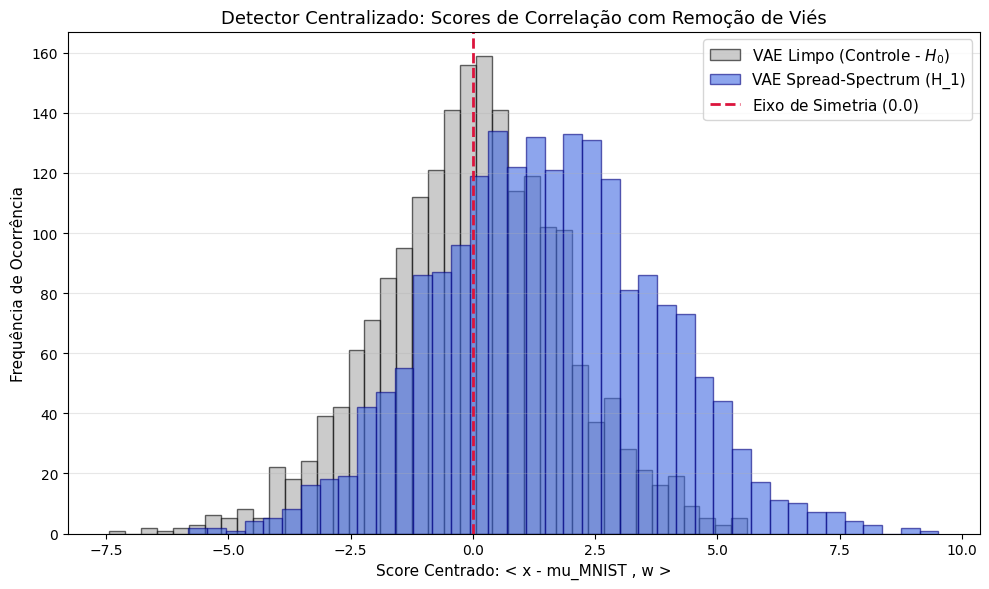


| Modelo Analisado      | Média dos Scores Centrados |
| VAE Limpo (Controle)  | -0.0147                     |
| VAE Spread-Spectrum   | 1.5164                     |


In [21]:
def corr_score_centered(imgs, pattern, mean_img):
    # imgs: formato (B, 1, 28, 28) ou (B, 784)
    # pattern: formato (1, 28, 28) ou (784,)
    # mean_img: formato (1, 28, 28) ou (784,) -> mu_mnist calculado na 3.5
    
    B = imgs.size(0)
    
    imgs_flat = imgs.view(B, -1)
    pattern_flat = pattern.view(-1)
    mean_img_flat = mean_img.view(-1)
    
    imgs_centered = imgs_flat - mean_img_flat

    scores = torch.matmul(imgs_centered, pattern_flat)
    
    return scores


model.eval()
vae_ss.eval()

mu_mnist = mu_mnist.to(device)
wm_pattern = wm_pattern.to(device)

with torch.no_grad():
    scores_clean_centered = corr_score_centered(imgs_clean, wm_pattern, mu_mnist).cpu().numpy()
    scores_ss_centered = corr_score_centered(imgs_ss, wm_pattern, mu_mnist).cpu().numpy()


plt.figure(figsize=(10, 6))
plt.hist(scores_clean_centered, bins=40, alpha=0.6, 
         label='VAE Limpo (Controle - $H_0$)', color='darkgray', edgecolor='black')

plt.hist(scores_ss_centered, bins=40, alpha=0.6, 
         label='VAE Spread-Spectrum (H_1)', color='royalblue', edgecolor='navy')


plt.axvline(x=0, color='crimson', linestyle='--', linewidth=2, label='Eixo de Simetria ($0.0$)')

plt.title("Detector Centralizado: Scores de Correlação com Remoção de Viés", fontsize=13)
plt.xlabel("Score Centrado: < x - mu_MNIST , w >", fontsize=11)
plt.ylabel("Frequência de Ocorrência", fontsize=11)
plt.legend(fontsize=11, loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n| Modelo Analisado      | Média dos Scores Centrados |")
print(f"| VAE Limpo (Controle)  | {np.mean(scores_clean_centered):.4f}                     |")
print(f"| VAE Spread-Spectrum   | {np.mean(scores_ss_centered):.4f}                     |")

### 3.7 Teste de hipótese

Com os scores centralizados, formalizamos a auditoria como um **teste de duas amostras**. O auditor gera $N$ amostras independentes do modelo suspeito e $N$ amostras independentes de um modelo de referência limpo, e testa se as médias diferem:

$$t = \frac{\bar{s}_{\text{ss}} - \bar{s}_{\text{clean}}}{\sqrt{(\hat{\sigma}_{\text{ss}}^2 + \hat{\sigma}_{\text{clean}}^2)/N}}$$

**Tarefa 3.7.** Gere 2000 amostras independentes de cada modelo (use `torch.randn` separado para cada). Compute `sc_clean`, `sc_ss` e o t-estatístico acima. Plote os histogramas e imprima o t-estatístico.

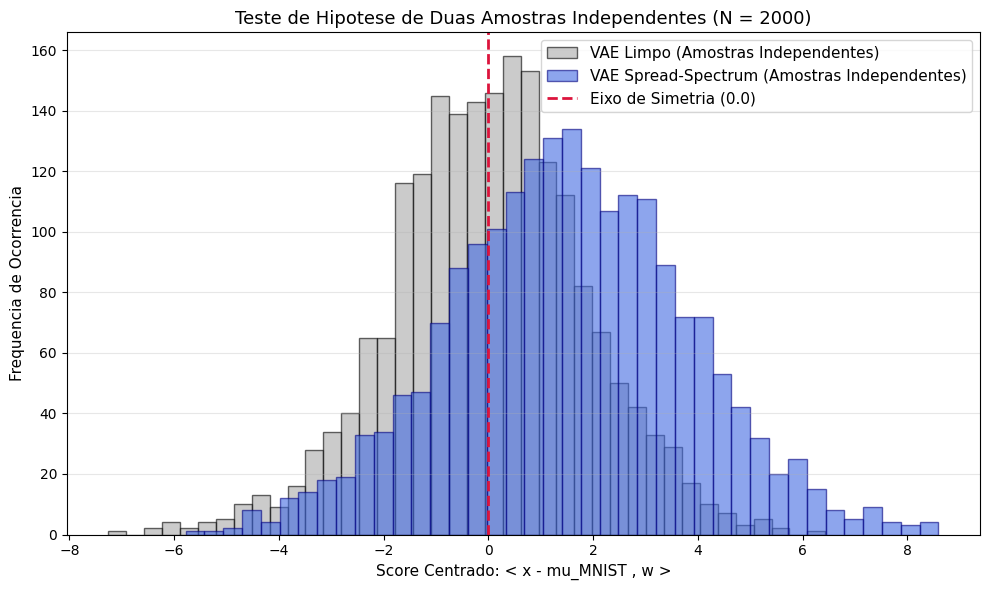

       RESULTADOS DO TESTE T DE DUAS AMOSTRAS     
Media dos Scores (VAE Limpo):          -0.0071
Media dos Scores (VAE Spread-Spectrum): 1.5198
--------------------------------------------------
Variancia Amostral (VAE Limpo):        3.4366
Variancia Amostral (VAE Spread-Spec):  5.2462
--------------------------------------------------
T-ESTATISTICO CALCULADO:                23.1730


In [22]:
N_AUDIT = 2000

model.eval()
vae_ss.eval()

mu_mnist = mu_mnist.to(device)
wm_pattern = wm_pattern.to(device)

with torch.no_grad():
    
    z_clean = torch.randn(N_AUDIT, LATENT_DIM).to(device)
    z_ss = torch.randn(N_AUDIT, LATENT_DIM).to(device)
    
   
    imgs_clean = model.decoder(z_clean)
    imgs_ss = vae_ss.decoder(z_ss)
    
    
    if isinstance(imgs_clean, tuple): imgs_clean = imgs_clean[0]
    if isinstance(imgs_ss, tuple): imgs_ss = imgs_ss[0]
    
    
    sc_clean = corr_score_centered(imgs_clean, wm_pattern, mu_mnist).cpu().numpy()
    sc_ss = corr_score_centered(imgs_ss, wm_pattern, mu_mnist).cpu().numpy()

#  Calcula as metricas estatisticas necessarias 
mean_clean = np.mean(sc_clean)
mean_ss = np.mean(sc_ss)

var_clean = np.var(sc_clean, ddof=1)  # Variancia amostral 
var_ss = np.var(sc_ss, ddof=1)

# formula do t-estatistico 
t_stat = (mean_ss - mean_clean) / np.sqrt((var_ss + var_clean) / N_AUDIT)


plt.figure(figsize=(10, 6))

plt.hist(sc_clean, bins=40, alpha=0.6, 
         label='VAE Limpo (Amostras Independentes)', color='darkgray', edgecolor='black')
plt.hist(sc_ss, bins=40, alpha=0.6, 
         label='VAE Spread-Spectrum (Amostras Independentes)', color='royalblue', edgecolor='navy')

plt.axvline(x=0, color='crimson', linestyle='--', linewidth=2, label='Eixo de Simetria (0.0)')


plt.title("Teste de Hipotese de Duas Amostras Independentes (N = 2000)", fontsize=13)
plt.xlabel("Score Centrado: < x - mu_MNIST , w >", fontsize=11)
plt.ylabel("Frequencia de Ocorrencia", fontsize=11)
plt.legend(fontsize=11, loc='upper right')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("==================================================")
print("       RESULTADOS DO TESTE T DE DUAS AMOSTRAS     ")
print("==================================================")
print(f"Media dos Scores (VAE Limpo):          {mean_clean:.4f}")
print(f"Media dos Scores (VAE Spread-Spectrum): {mean_ss:.4f}")
print("--------------------------------------------------")
print(f"Variancia Amostral (VAE Limpo):        {var_clean:.4f}")
print(f"Variancia Amostral (VAE Spread-Spec):  {var_ss:.4f}")
print("--------------------------------------------------")
print(f"T-ESTATISTICO CALCULADO:                {t_stat:.4f}")
print("==================================================")

### Questão 3 — Análise do detector spread-spectrum

**a)** Descreva o histograma ingênuo (Tarefa 3.4): os dois grupos estão centrados onde você esperaria? Você conseguiria detectar a marca sem ajustes?

**b)** Explique matematicamente por que o VAE limpo não está centrado em zero. Reporte o valor de $\langle \mu_\text{MNIST}, w \rangle$ que você calculou e compare com a média observada no histograma.

**c)** Após os fixes (Tarefa 3.6), os histogramas estão centrados e separados? Reporte o t-estatístico e interprete: a marca é detectável com N=2000?

**Questão a)**


**Questão b)**

**Questão c)**


## Parte 4 — Estudo controlado: quanto sinal e quantos dados?

A Parte 3 usou uma única configuração ($\varepsilon = 0.10$, fração $= 0.20$). Aqui mapeamos sistematicamente como a detectabilidade depende dessas escolhas.

> *Dica: você pode usar menos épocas por VAE na varredura para reduzir o tempo de execução. Se fizer isso, retreine o VAE limpo com o mesmo número de épocas antes da varredura — a comparação só é justa quando todos os modelos treinam sob as mesmas condições.*

### 4.1 Fábrica de datasets

**Tarefa 4.1.** Implemente `make_ss_dataset(eps, fraction)` que cria um dataset com `fraction` das imagens marcadas com amplitude `eps`.

In [35]:
# TODO: escolha pelo menos 2 valores para cada parâmetro
EPSILON_VALUES  = [0.02, 0.05, 0.10]   # ex: [0.05, 0.10]
FRACTION_VALUES = [0.05, 0.10, 0.20]   # ex: [0.10, 0.20]
N_AUDIT         = 2000    # fixo
EPOCHS_ABLATION = 30     # pode ser menor que EPOCHS — veja a dica acima

In [36]:
def make_ss_dataset(eps, fraction, seed=SEED):
    # Retorna um Dataset que aplica a marca em `fraction` das imagens de treino
    # com amplitude `eps` (determinístico via `seed`).
    class _SSDataset(Dataset):
        def __init__(self, base_dataset, eps, fraction, seed):
            self.base = base_dataset
            self.eps = float(eps)
            # Usa o padrão global `wm_pattern` escalado pela amplitude eps (mantendo média ~0)
            # Mantemos o padrão em CPU para aplicar sem depender do device do modelo.
            self.wm = (wm_pattern.clone() * self.eps).to("cpu")
            num = len(self.base)
            num_wm = int(num * fraction)
            rng = np.random.default_rng(seed)
            chosen = rng.choice(num, size=num_wm, replace=False)
            self.wm_indices = sorted(list(chosen))
            self.wm_set = set(self.wm_indices)

        def __len__(self):
            return len(self.base)

        def __getitem__(self, idx):
            img, label = self.base[idx]
            # img pode estar em CPU já; aplica marca apenas se index sorteado
            if idx in self.wm_set:
                img = torch.clamp(img + self.wm, 0.0, 1.0)
            return img, label

    return _SSDataset(train_ds, eps, fraction, seed)

# Retreina o VAE limpo com EPOCHS_ABLATION para comparação justa
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

train_loader_ab = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
model_ab = train_vae(train_loader_ab, LATENT_DIM, EPOCHS_ABLATION, label="clean_ablation")



--- Iniciando Treinamento do VAE [CLEAN_ABLATION] (LATENT_DIM=8) ---
[CLEAN_ABLATION] Ep   1/30 | Loss: 194.91 | Recon: 190.17 | KL: 4.74
[CLEAN_ABLATION] Ep   5/30 | Loss: 116.20 | Recon: 101.12 | KL: 15.08
[CLEAN_ABLATION] Ep  10/30 | Loss: 109.75 | Recon: 93.89 | KL: 15.86
[CLEAN_ABLATION] Ep  15/30 | Loss: 106.74 | Recon: 90.53 | KL: 16.21
[CLEAN_ABLATION] Ep  20/30 | Loss: 104.91 | Recon: 88.45 | KL: 16.47
[CLEAN_ABLATION] Ep  25/30 | Loss: 103.57 | Recon: 86.95 | KL: 16.63
[CLEAN_ABLATION] Ep  30/30 | Loss: 102.59 | Recon: 85.83 | KL: 16.76


### 4.2 Varredura

**Tarefa 4.2.** Execute a varredura sobre a grade `EPSILON_VALUES × FRACTION_VALUES` (o `model_ab` já foi retreinado na 4.1 acima):
1. Para cada (ε, fração), treine um VAE marcado com `EPOCHS_ABLATION` épocas.
2. Para cada par, gere `N_AUDIT` amostras **independentes** de `model_ab` e do VAE marcado.
3. Compute o t-estatístico de duas amostras (mesma fórmula da Parte 3.7) e registre o sinal médio.

Guarde os resultados numa lista de dicts com chaves `eps`, `frac`, `signal`, `t`.

In [37]:
import pandas as pd
# TODO: implementar a varredura
# Para cada (eps, frac) em EPSILON_VALUES × FRACTION_VALUES:
#   1. Crie o dataset com make_ss_dataset(eps, frac)
#   2. Treine um VAE com EPOCHS_ABLATION épocas
#   3. Gere N_AUDIT amostras INDEPENDENTES de model_ab e do VAE marcado
#   4. Compute o t-estatístico de duas amostras e o sinal médio
#   5. Guarde em results como dict {"eps": ..., "frac": ..., "signal": ..., "t": ...}
results = []

for eps in EPSILON_VALUES:
    for frac in FRACTION_VALUES:
        print(f"\n--- Scan: eps={eps}  frac={frac} ---")
        # Cria dataset marcado
        ss_dataset = make_ss_dataset(eps, frac, seed=SEED)
        ss_loader = DataLoader(ss_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)

        # Treina um VAE marcado (mesmas condições do modelo_ab)
        torch.manual_seed(SEED)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(SEED)

        label = f"ss_eps{eps}_frac{int(frac*100)}"
        vae_marked = train_vae(ss_loader, LATENT_DIM, EPOCHS_ABLATION, label=label, lr=1e-3)
        vae_marked.eval()
        model_ab.eval()

        # Gera N_AUDIT amostras independentes de cada modelo
        with torch.no_grad():
            z_clean = torch.randn(N_AUDIT, LATENT_DIM).to(device)
            z_wm    = torch.randn(N_AUDIT, LATENT_DIM).to(device)

            imgs_clean = model_ab.decoder(z_clean)
            imgs_wm    = vae_marked.decoder(z_wm)

            # Computa scores centralizados e estatísticas
            sc_clean = corr_score_centered(imgs_clean, wm_pattern.to(device), mu_mnist.to(device)).cpu().numpy()
            sc_wm    = corr_score_centered(imgs_wm, wm_pattern.to(device), mu_mnist.to(device)).cpu().numpy()

        mean_clean = np.mean(sc_clean)
        mean_wm    = np.mean(sc_wm)
        signal = mean_wm - mean_clean

        var_clean = np.var(sc_clean, ddof=1)
        var_wm    = np.var(sc_wm, ddof=1)

        t_stat = (mean_wm - mean_clean) / np.sqrt((var_wm + var_clean) / N_AUDIT)

        results.append({
            "eps": float(eps),
            "frac": float(frac),
            "signal": float(signal),
            "t": float(t_stat),
            "mean_wm": float(mean_wm),
            "mean_clean": float(mean_clean),
            "var_wm": float(var_wm),
            "var_clean": float(var_clean)
        })

        print(f"eps={eps} frac={frac} | signal={signal:.6e} | t={t_stat:.3f} | mean_wm={mean_wm:.6e} mean_clean={mean_clean:.6e}")

df_results = pd.DataFrame(results)
df_results.to_csv(output_dir / "ablation_results.csv", index=False)
print("\nVarredura completa. Resultados salvos em:", output_dir / "ablation_results.csv")


--- Scan: eps=0.02  frac=0.05 ---

--- Iniciando Treinamento do VAE [SS_EPS0.02_FRAC5] (LATENT_DIM=8) ---
[SS_EPS0.02_FRAC5] Ep   1/30 | Loss: 195.17 | Recon: 190.49 | KL: 4.69
[SS_EPS0.02_FRAC5] Ep   5/30 | Loss: 117.28 | Recon: 102.37 | KL: 14.92
[SS_EPS0.02_FRAC5] Ep  10/30 | Loss: 110.68 | Recon: 94.93 | KL: 15.75
[SS_EPS0.02_FRAC5] Ep  15/30 | Loss: 107.79 | Recon: 91.65 | KL: 16.14
[SS_EPS0.02_FRAC5] Ep  20/30 | Loss: 105.96 | Recon: 89.57 | KL: 16.39
[SS_EPS0.02_FRAC5] Ep  25/30 | Loss: 104.67 | Recon: 88.11 | KL: 16.56
[SS_EPS0.02_FRAC5] Ep  30/30 | Loss: 103.70 | Recon: 87.01 | KL: 16.69
eps=0.02 frac=0.05 | signal=7.360066e-02 | t=1.257 | mean_wm=1.902045e-01 mean_clean=1.166038e-01

--- Scan: eps=0.02  frac=0.1 ---

--- Iniciando Treinamento do VAE [SS_EPS0.02_FRAC10] (LATENT_DIM=8) ---
[SS_EPS0.02_FRAC10] Ep   1/30 | Loss: 195.37 | Recon: 190.62 | KL: 4.75
[SS_EPS0.02_FRAC10] Ep   5/30 | Loss: 118.74 | Recon: 104.12 | KL: 14.62
[SS_EPS0.02_FRAC10] Ep  10/30 | Loss: 111.07 

### 4.3 Visualização dos resultados

**Tarefa 4.3.** Plote dois heatmaps com eixos $(\varepsilon, \text{fração})$:
1. Sinal médio $\bar{d} = \bar{s}_{\text{wm}} - \bar{s}_{\text{clean}}$.
2. T-estatístico (duas amostras independentes).

Anote o valor em cada célula do heatmap.

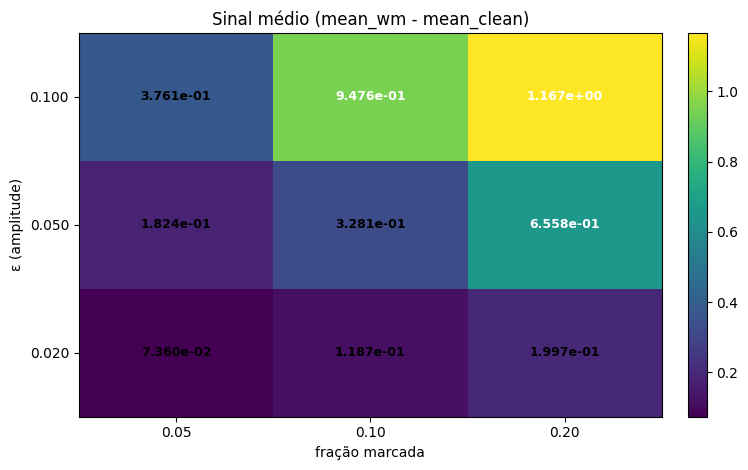

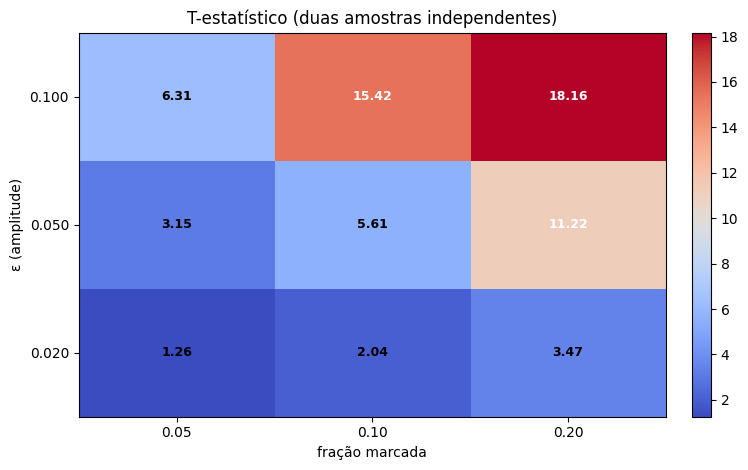


Resultados (resumo):


signal                             t                      
frac      0.05      0.10      0.20      0.05       0.10       0.20
eps                                                               
0.02  0.073601  0.118692  0.199661  1.256622   2.044564   3.470346
0.05  0.182408  0.328097  0.655782  3.150820   5.608754  11.217900
0.10  0.376142  0.947626  1.166953  6.310564  15.423554  18.163017

In [38]:
# TODO: heatmap signal_grid, heatmap t_grid
# Heatmaps: sinal médio e t-estatístico 
import numpy as np
import matplotlib.pyplot as plt

# assegura que df_results existe
try:
    df = df_results.copy()
except NameError:
    df = pd.read_csv(output_dir / "ablation_results.csv")

# Ordenamento consistente
eps_vals = EPSILON_VALUES
frac_vals = FRACTION_VALUES

signal_grid = np.zeros((len(eps_vals), len(frac_vals)))
t_grid = np.zeros_like(signal_grid)

for i, eps in enumerate(eps_vals):
    for j, frac in enumerate(frac_vals):
        sel = df[(np.isclose(df["eps"].astype(float), float(eps))) &
                 (np.isclose(df["frac"].astype(float), float(frac)))]
        if len(sel) == 0:
            val_signal = np.nan
            val_t = np.nan
        else:
            # se houve múltiplas execuções, use a média
            val_signal = sel["signal"].astype(float).mean()
            val_t = sel["t"].astype(float).mean()
        signal_grid[i, j] = val_signal
        t_grid[i, j] = val_t

def plot_annotated_heatmap(grid, row_labels, col_labels, title, cmap, fmt, filename):
    fig, ax = plt.subplots(figsize=(4 + len(col_labels)*1.2, 3 + len(row_labels)*0.6))
    im = ax.imshow(grid, origin="lower", cmap=cmap, aspect="auto")
    ax.set_xticks(np.arange(len(col_labels)))
    ax.set_yticks(np.arange(len(row_labels)))
    ax.set_xticklabels([f"{c:.2f}" for c in col_labels])
    ax.set_yticklabels([f"{r:.3f}" if r < 1 else f"{r:.2f}" for r in row_labels])
    ax.set_xlabel("fração marcada")
    ax.set_ylabel("ε (amplitude)")
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # Anotar valores em cada célula
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            v = grid[i, j]
            txt = "nan" if np.isnan(v) else (fmt.format(v))
            ax.text(j, i, txt, ha="center", va="center", color="white" if not np.isnan(v) and abs(v) > (np.nanmax(np.abs(grid)) * 0.5) else "black",
                    fontsize=9, fontweight="bold")
    plt.tight_layout()
    plt.savefig(output_dir / filename, dpi=150)
    plt.show()

# Signal heatmap 
plot_annotated_heatmap(signal_grid, eps_vals, frac_vals,
                       title="Sinal médio (mean_wm - mean_clean)",
                       cmap="viridis",
                       fmt="{:.3e}",
                       filename="4.3_signal_heatmap.png")

# T-statistic heatmap
plot_annotated_heatmap(t_grid, eps_vals, frac_vals,
                       title="T-estatístico (duas amostras independentes)",
                       cmap="coolwarm",
                       fmt="{:.2f}",
                       filename="4.3_tstat_heatmap.png")


print("\nResultados (resumo):")
display(df.pivot(index="eps", columns="frac", values=["signal", "t"]))

### Questão 4 — Análise dos resultados da ablação

**a)** Olhando o heatmap de sinal médio, como $\bar{d}$ cresce com $\varepsilon$ e com a fração? O crescimento é aproximadamente linear em cada eixo? Use 2–3 pares de células para justificar com números.

**b)** No heatmap de t-estatístico, qual é a menor combinação $(\varepsilon, \text{fração})$ que atinge $|t| > 3$? Existem células onde a marca não foi detectável mesmo com N=2000?

**c)** Com base nos seus resultados, qual é o par $(\varepsilon, \text{fração})$ mínimo que você recomendaria para um cenário de auditoria real? Justifique considerando tanto a detectabilidade quanto o custo de marcar os dados.

*Escreva suas respostas aqui (a, b, c).*

## Parte 5 — Extensões (Bônus)

Esta parte é **opcional**. **Escolha *uma* das duas questões abaixo** e implemente-a. Isso rende +10% na nota final.

### 5.1 — Robustez da marca a um ataque defensivo

Suponha que o dono do modelo gerador, sabendo que pode existir uma marca spread-spectrum, aplica um filtro às amostras antes de liberá-las. Implemente o ataque mais simples possível: **blur Gaussiano** nas amostras do `vae_ss` antes de calcular o score.

Rode o detector centralizado da Parte 3 em três condições: (i) sem ataque, (ii) blur com $\sigma=0.5$, (iii) blur com $\sigma=1.0$. Use $\varepsilon=0.10$, frac $=0.20$, $N=2000$.

Reporte os três valores de $t$ numa tabela e responda: o sinal sobrevive? A partir de que $\sigma$ a marca se torna indetectável ($|t| < 3$)?

*Escreva sua resposta aqui (tabela + análise).*

### 5.2 — Efeito da capacidade do canal latente

Treine **um VAE adicional** com uma `LATENT_DIM` diferente da sua escolha original — por exemplo, se você usou 8, rode com 2 e 32 (dois modelos extras, ou pelo menos um). Mantenha o restante do pipeline igual.

Refaça a auditoria da Parte 3 ($t$ em $\varepsilon=0.10$, frac $=0.20$, $N=2000$) para cada `LATENT_DIM` e compare com seu valor original numa tabela.

Em qual direção o $t$ se move quando o latente cresce? Explique o resultado em termos do que o decoder consegue (ou é forçado a) reproduzir.

In [27]:
# ...existing code...
# Célula: Implementação da Parte 5.2 — Efeito da capacidade do canal latente

import pandas as pd
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Configuração do experimento
LATENT_DIMS = [2, LATENT_DIM, 32]   # experimente 2, sua escolha original, e 32
EPS = 0.10
FRAC = 0.20
N_AUDIT = 2000
EPOCHS_5_2 = EPOCHS  # mantém o mesmo número de épocas do pipeline

rows = []

for d in LATENT_DIMS:
    print(f"\n--- Latent dim = {d} — treinando modelo limpo e modelo SS ---")

    # Treina VAE limpo com latent_dim = d
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
    train_loader_d = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
    model_d = train_vae(train_loader_d, latent_dim=d, epochs=EPOCHS_5_2, label=f"clean_lat{d}")
    model_d.eval()

    # Cria dataset spread-spectrum com (EPS, FRAC) e treina VAE marcado com latent_dim = d
    ss_ds_d = make_ss_dataset(EPS, FRAC, seed=SEED)
    ss_loader_d = DataLoader(ss_ds_d, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)

    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
    vae_ss_d = train_vae(ss_loader_d, latent_dim=d, epochs=EPOCHS_5_2, label=f"ss_lat{d}")
    vae_ss_d.eval()

    # Auditoria: gera amostras independentes e calcula t (usando corr_score_centered)
    with torch.no_grad():
        z_clean = torch.randn(N_AUDIT, d).to(device)
        z_ss    = torch.randn(N_AUDIT, d).to(device)

        imgs_clean = model_d.decoder(z_clean)
        imgs_ss    = vae_ss_d.decoder(z_ss)

        sc_clean = corr_score_centered(imgs_clean, wm_pattern.to(device), mu_mnist.to(device)).cpu().numpy()
        sc_ss    = corr_score_centered(imgs_ss,    wm_pattern.to(device), mu_mnist.to(device)).cpu().numpy()

    mean_clean = np.mean(sc_clean)
    mean_ss    = np.mean(sc_ss)
    var_clean  = np.var(sc_clean, ddof=1)
    var_ss     = np.var(sc_ss, ddof=1)

    t_stat = (mean_ss - mean_clean) / np.sqrt((var_ss + var_clean) / N_AUDIT)
    signal = mean_ss - mean_clean

    rows.append({
        "latent_dim": int(d),
        "eps": float(EPS),
        "frac": float(FRAC),
        "signal": float(signal),
        "t": float(t_stat),
        "mean_ss": float(mean_ss),
        "mean_clean": float(mean_clean),
        "var_ss": float(var_ss),
        "var_clean": float(var_clean)
    })

    print(f"latent={d} | signal={signal:.3e} | t={t_stat:.3f} | mean_ss={mean_ss:.3e} mean_clean={mean_clean:.3e}")

# Resultado em tabela
df_latent = pd.DataFrame(rows).sort_values("latent_dim").reset_index(drop=True)
df_latent.to_csv(output_dir / "5.2_latent_dim_results.csv", index=False)
print("\nResultados salvos em:", output_dir / "5.2_latent_dim_results.csv")
print("\nResumo:")


--- Latent dim = 2 — treinando modelo limpo e modelo SS ---

--- Iniciando Treinamento do VAE [CLEAN_LAT2] (LATENT_DIM=2) ---
[CLEAN_LAT2] Ep   1/30 | Loss: 196.18 | Recon: 192.84 | KL: 3.34
[CLEAN_LAT2] Ep   5/30 | Loss: 152.90 | Recon: 147.15 | KL: 5.75
[CLEAN_LAT2] Ep  10/30 | Loss: 146.11 | Recon: 139.92 | KL: 6.18
[CLEAN_LAT2] Ep  15/30 | Loss: 142.74 | Recon: 136.36 | KL: 6.38
[CLEAN_LAT2] Ep  20/30 | Loss: 140.88 | Recon: 134.34 | KL: 6.54
[CLEAN_LAT2] Ep  25/30 | Loss: 139.41 | Recon: 132.77 | KL: 6.64
[CLEAN_LAT2] Ep  30/30 | Loss: 138.35 | Recon: 131.62 | KL: 6.73

--- Iniciando Treinamento do VAE [SS_LAT2] (LATENT_DIM=2) ---
[SS_LAT2] Ep   1/30 | Loss: 203.06 | Recon: 199.87 | KL: 3.19
[SS_LAT2] Ep   5/30 | Loss: 161.32 | Recon: 155.61 | KL: 5.71
[SS_LAT2] Ep  10/30 | Loss: 154.04 | Recon: 147.87 | KL: 6.17
[SS_LAT2] Ep  15/30 | Loss: 150.91 | Recon: 144.55 | KL: 6.36
[SS_LAT2] Ep  20/30 | Loss: 149.04 | Recon: 142.54 | KL: 6.50
[SS_LAT2] Ep  25/30 | Loss: 147.82 | Recon: 1

*Escreva sua resposta aqui (tabela + análise).*

---

## Critérios de avaliação

| Parte | Peso | Critério |
|-------|------|----------|
| 0–1   | 20%  | VAE correto e visualizações. Q1. |
| 2     | 20%  | Marca visível e auditoria. Q2. |
| 3     | 30%  | Spread-spectrum, diagnóstico do offset, detector centralizado, teste. Q3. |
| 4     | 30%  | Ablação completa e heatmaps. Q4 com análise quantitativa. |
| 5 (bônus) | +10% | Uma das duas extensões opcionais (5.1 ou 5.2). |